In [3]:
import ipdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pylab as pylab
import cartopy
import cartopy.crs as ccrs
import pickle as pkl
import glob
from metpy import calc
from metpy.units import units

from shared.paths import load_paths
paths = load_paths()

pylab.rcParams['figure.figsize'] = (10., 10.)
%matplotlib inline

In [4]:
#cp4_path = '/gws/nopw/j04/lmcs/cklein/CP_models/MCS_files/WAf/CP4_box_JASMIN/instantaneous_18h_v1/'

cp4_path = paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/'

In [5]:
paths.lmcs_figs

'/gws/ssde/j25b/cocoon/figs/LMCS'

In [6]:
import numpy as np
import xarray as xr


EARTH_RADIUS = 6_371_000.0  # metres


def _get_horizontal_distance_m(
    da,
    dim,
    coord_units="km",
    latitude_for_lon=None,
):
    """
    Convert the horizontal coordinate of a cross-section to metres.

    Parameters
    ----------
    da : xr.DataArray
        Wind component data array.

    dim : str
        Horizontal dimension along which to differentiate.

    coord_units : str
        Either:
        - "km"     : coordinate is already distance in kilometres
        - "m"      : coordinate is already distance in metres
        - "latlon" : coordinate is latitude or longitude in degrees

    latitude_for_lon : float, optional
        Representative latitude needed only if dim is longitude
        and coord_units="latlon".

    Returns
    -------
    coord_m : xr.DataArray
        Horizontal coordinate converted to metres.
    """

    coord = da[dim]

    if coord_units == "m":
        coord_m = coord

    elif coord_units == "km":
        coord_m = coord * 1000.0

    elif coord_units == "latlon":
        dim_lower = dim.lower()

        if dim_lower in ["latitude", "lat"]:
            coord_m = np.deg2rad(coord) * EARTH_RADIUS

        elif dim_lower in ["longitude", "lon"]:
            if latitude_for_lon is None:
                raise ValueError(
                    "For longitude in degrees, please provide latitude_for_lon, "
                    "e.g. latitude_for_lon=10.0"
                )

            coord_m = (
                np.deg2rad(coord)
                * EARTH_RADIUS
                * np.cos(np.deg2rad(latitude_for_lon))
            )

        else:
            raise ValueError(
                f"coord_units='latlon' only works with latitude/lat or "
                f"longitude/lon dimensions. Got dim={dim!r}."
            )

    else:
        raise ValueError("coord_units must be one of 'km', 'm', or 'latlon'.")

    return xr.DataArray(coord_m, dims=dim, coords={dim: coord})

def cross_section_divergence_or_convergence(
    ds,
    direction,
    quantity="convergence",
    u_name="u_cross",
    v_name="v_cross",
    x_dim=None,
    y_dim=None,
    coord_units="km",
    latitude_for_lon=None,
):
    """
    Calculate along-section divergence or convergence from a cross-section.

    For XDIR:
        divergence  = du/dx
        convergence = -du/dx

    For YDIR:
        divergence  = dv/dy
        convergence = -dv/dy

    Parameters
    ----------
    ds : xr.Dataset
        Dataset containing u and/or v cross-section wind components.

    direction : str
        Either "XDIR" or "YDIR".

    quantity : str
        Either "divergence" or "convergence".

    u_name : str
        Name of u wind component.

    v_name : str
        Name of v wind component.

    x_dim : str, optional
        Horizontal dimension for XDIR.
        Only needed if direction="XDIR".
        For example: "x", "longitude", "lon".

    y_dim : str, optional
        Horizontal dimension for YDIR.
        Only needed if direction="YDIR".
        For example: "y", "latitude", "lat".

    coord_units : str
        Either:
        - "km"     : horizontal coordinate is in km
        - "m"      : horizontal coordinate is in m
        - "latlon" : horizontal coordinate is latitude/longitude in degrees

    latitude_for_lon : float, optional
        Representative latitude required only when differentiating along
        longitude with coord_units="latlon".

    Returns
    -------
    out : xr.DataArray
        Divergence or convergence in s^-1.
    """

    direction = direction.lower()
    quantity = quantity.lower()

    if quantity not in ["divergence", "convergence"]:
        raise ValueError("quantity must be either 'divergence' or 'convergence'.")

    if direction in ["x", "xdir"]:
        if x_dim is None:
            # Try to infer a sensible x dimension
            for candidate in ["x", "longitude", "lon"]:
                if candidate in ds[u_name].dims:
                    x_dim = candidate
                    break

        if x_dim is None:
            raise ValueError(
                "For direction='XDIR', provide x_dim, e.g. x_dim='x' "
                "or x_dim='longitude'."
            )

        da = ds[u_name]
        dim = x_dim
        derivative_name = "du_dx"

    elif direction in ["y", "ydir"]:
        if y_dim is None:
            # Try to infer a sensible y dimension
            for candidate in ["y", "latitude", "lat"]:
                if candidate in ds[v_name].dims:
                    y_dim = candidate
                    break

        if y_dim is None:
            raise ValueError(
                "For direction='YDIR', provide y_dim, e.g. y_dim='y' "
                "or y_dim='latitude'."
            )

        da = ds[v_name]
        dim = y_dim
        derivative_name = "dv_dy"

    else:
        raise ValueError("direction must be either 'XDIR' or 'YDIR'.")

    if dim not in da.dims:
        raise ValueError(f"{dim!r} is not a dimension of {da.name!r}.")

    coord_m = _get_horizontal_distance_m(
        da,
        dim=dim,
        coord_units=coord_units,
        latitude_for_lon=latitude_for_lon,
    )

    da_m = da.assign_coords({dim: coord_m})

    divergence = da_m.differentiate(dim)
    divergence.name = derivative_name
    divergence.attrs["units"] = "s-1"

    if quantity == "divergence":
        out = divergence
        out.attrs["long_name"] = f"along-section divergence {derivative_name}"

    else:
        out = -divergence
        out.name = derivative_name.replace("d", "convergence_from_d", 1)
        out.attrs["long_name"] = f"along-section convergence from {derivative_name}"
        out.attrs["units"] = "s-1"

    return out

In [7]:
def get_clim(direction='XDIR', strs='17'):

    file = 'hist_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'
    filem = 'hist_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'
    file2 = 'fut_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'
    file2m = 'fut_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'
    
    file2d = 'hist_anom_Jul-Sep_'+strs+'h_2d.nc'
    file2d2 = 'fut_anom_Jul-Sep_'+strs+'h_2d.nc'
    file2d_mean = 'hist_mean_Jul-Sep_'+strs+'h_2d.nc'
    file2d2_mean = 'fut_mean_Jul-Sep_'+strs+'h_2d.nc'

    sliceval= [-6 ,-6]   # -6,6
    
    ###########################
    
    ds = xr.open_dataset(cp4_path+file)
    ds2 = xr.open_dataset(cp4_path+file2)
    
    ds_mean = xr.open_dataset(cp4_path+filem)
    ds2_mean = xr.open_dataset(cp4_path+file2m)
    
    #######################################
    
    ds2d = xr.open_dataset(cp4_path+file2d)
    ds2d2 = xr.open_dataset(cp4_path+file2d2)
    
    
    if direction == 'XDIR':
        ds2d = ds2d.sel(latitude=slice(sliceval[0],sliceval[1])).mean('latitude')
        ds2d2 = ds2d2.sel(latitude=slice(sliceval[0],sliceval[1])).mean('latitude')
    if direction == 'YDIR':
        ds2d = ds2d.sel(longitude=slice(sliceval[0],sliceval[1])).mean('longitude')
        ds2d2 = ds2d2.sel(longitude=slice(sliceval[0],sliceval[1])).mean('longitude')
    ds3 = ds2d[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross', 'v_srfc' : 'v_cross'})
    ds32 = ds2d2[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross',  'v_srfc' : 'v_cross'})
    
    merged_hist = ds[['t_cross', 'q_cross', 'u_cross', 'v_cross']]
    merged_fut = ds2[['t_cross', 'q_cross', 'u_cross', 'v_cross']]
    
    # Add pressure level dimension to the extra dataset
    pressure_level_980 = 980  # Define the pressure level value
    ds3 = ds3.expand_dims(dim={'pressure': [pressure_level_980]})
    ds3 = ds3.assign_coords(pressure=('pressure', [pressure_level_980]))
    merged_hist = xr.concat([ds3, merged_hist], dim='pressure')
    
    ds32 = ds32.expand_dims(dim={'pressure': [pressure_level_980]})
    ds32 = ds32.assign_coords(pressure=('pressure', [pressure_level_980]))
    merged_fut = xr.concat([ds32, merged_fut], dim='pressure')
    
    #####################################
    
    #######################################
    
    ds2d = xr.open_dataset(cp4_path+file2d_mean)
    ds2d2 = xr.open_dataset(cp4_path+file2d2_mean)

    
    if direction == 'XDIR':
        ds2d = ds2d.sel(latitude=slice(sliceval[0],sliceval[1])).mean('latitude')
        ds2d2 = ds2d2.sel(latitude=slice(sliceval[0],sliceval[1])).mean('latitude')
    if direction == 'YDIR':
        ds2d = ds2d.sel(longitude=slice(sliceval[0],sliceval[1])).mean('longitude')
        ds2d2 = ds2d2.sel(longitude=slice(sliceval[0],sliceval[1])).mean('longitude')
    ds3_m = ds2d[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross', 'v_srfc' : 'v_cross'})
    ds32_m = ds2d2[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross',  'v_srfc' : 'v_cross'})
    
    merged_hist_mean = ds_mean[['t_cross', 'q_cross', 'u_cross', 'v_cross']]
    merged_fut_mean = ds2_mean[['t_cross', 'q_cross', 'u_cross', 'v_cross']]
    
    # Add pressure level dimension to the extra dataset
    pressure_level_980 = 980  # Define the pressure level value
    ds3_m = ds3_m.expand_dims(dim={'pressure': [pressure_level_980]})
    ds3_m = ds3_m.assign_coords(pressure=('pressure', [pressure_level_980]))
    merged_hist_mean = xr.concat([ds3_m, merged_hist_mean], dim='pressure')
    
    ds32_m = ds32_m.expand_dims(dim={'pressure': [pressure_level_980]})
    ds32_m = ds32_m.assign_coords(pressure=('pressure', [pressure_level_980]))
    merged_fut_mean = xr.concat([ds32_m, merged_fut_mean], dim='pressure')
    
    merged_hist_clim = merged_hist_mean-merged_hist
    merged_fut_clim = merged_fut_mean-merged_fut

    return merged_hist_clim, merged_fut_clim

In [8]:
def get_anom_and_mean(period='hist', direction='XDIR', strs='17'):
    """
    Load CP4 anomaly and mean cross-section data for one period only.

    Parameters
    ----------
    period : str
        Either 'hist' or 'fut'.
    direction : str
        Either 'XDIR' or 'YDIR'.
    strs : str
        Hour string used in filenames, e.g. '17'.

    Returns
    -------
    merged_anom : xr.Dataset
        Cross-section anomaly dataset with 2D surface fields added at pressure=980.
    merged_mean : xr.Dataset
        Cross-section mean dataset with 2D surface fields added at pressure=980.
    """

    if period not in ['hist', 'fut']:
        raise ValueError("period must be either 'hist' or 'fut'")

    if direction not in ['XDIR', 'YDIR']:
        raise ValueError("direction must be either 'XDIR' or 'YDIR'")

    file_anom = f'{period}_anom_Jul-Sep_{strs}h_{direction}.nc'
    file_mean = f'{period}_mean_Jul-Sep_{strs}h_{direction}.nc'

    file_2d_anom = f'{period}_anom_Jul-Sep_{strs}h_2d.nc'
    file_2d_mean = f'{period}_mean_Jul-Sep_{strs}h_2d.nc'

    sliceval = [-6, 6]
    pressure_level_980 = 980

    # -------------------------
    # 3D cross-section files
    # -------------------------
    ds_anom = xr.open_dataset(cp4_path + file_anom)
    ds_mean = xr.open_dataset(cp4_path + file_mean)

    merged_anom = ds_anom[['t_cross', 'q_cross', 'u_cross', 'v_cross']]
    merged_mean = ds_mean[['t_cross', 'q_cross', 'u_cross', 'v_cross']]

    # -------------------------
    # 2D anomaly surface fields
    # -------------------------
    ds2d_anom = xr.open_dataset(cp4_path + file_2d_anom)

    if direction == 'XDIR':
        ds2d_anom = (
            ds2d_anom
            .sel(latitude=slice(sliceval[0], sliceval[1]))
            .mean('latitude')
        )

    elif direction == 'YDIR':
        ds2d_anom = (
            ds2d_anom
            .sel(longitude=slice(sliceval[0], sliceval[1]))
            .mean('longitude')
        )

    ds2d_anom = (
        ds2d_anom[['t2', 'q2', 'u_srfc', 'v_srfc']]
        .rename({
            't2': 't_cross',
            'q2': 'q_cross',
            'u_srfc': 'u_cross',
            'v_srfc': 'v_cross'
        })
        .expand_dims(dim={'pressure': [pressure_level_980]})
        .assign_coords(pressure=('pressure', [pressure_level_980]))
    )

    merged_anom = xr.concat([ds2d_anom, merged_anom], dim='pressure')

    # -------------------------
    # 2D mean surface fields
    # -------------------------
    ds2d_mean = xr.open_dataset(cp4_path + file_2d_mean)

    if direction == 'XDIR':
        ds2d_mean = (
            ds2d_mean
            .sel(latitude=slice(sliceval[0], sliceval[1]))
            .mean('latitude')
        )

    elif direction == 'YDIR':
        ds2d_mean = (
            ds2d_mean
            .sel(longitude=slice(sliceval[0], sliceval[1]))
            .mean('longitude')
        )

    ds2d_mean = (
        ds2d_mean[['t2', 'q2', 'u_srfc', 'v_srfc']]
        .rename({
            't2': 't_cross',
            'q2': 'q_cross',
            'u_srfc': 'u_cross',
            'v_srfc': 'v_cross'
        })
        .expand_dims(dim={'pressure': [pressure_level_980]})
        .assign_coords(pressure=('pressure', [pressure_level_980]))
    )

    merged_mean = xr.concat([ds2d_mean, merged_mean], dim='pressure')

    return merged_anom, merged_mean

In [9]:
tdat = xr.open_dataset('/home/users/cornkle/lmcs/cklein/CP_models/MCS_files/WAf/CP4_box_JASMIN/mean3h_v2/hist_mean_Jul-Sep_18h_XDIR.nc')

/tmp/ipykernel_3633/2010748863.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_3633/2010748863.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3633/2010748863.py:132: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_3633/2010748863.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


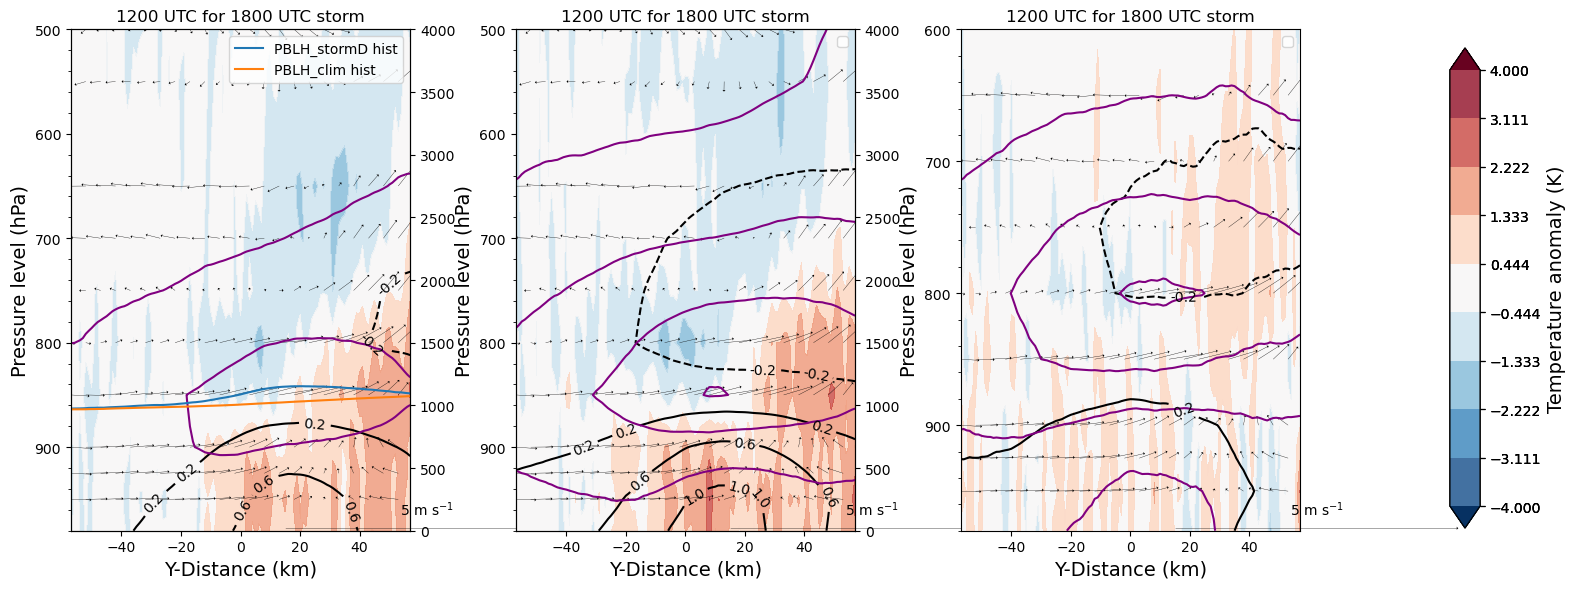

In [10]:
f = plt.figure(figsize=(15,6), dpi=100)

ticks = np.array([-57,-57/2,0,57/2,57])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]

strs='18'
direction='XDIR'

if direction == 'XDIR':
    xdim='longitude'
    u_name = 'u_cross'
else:
    xdim='latitude'
    u_name = 'v_cross'

merged_hist, merged_hist_mean = get_anom_and_mean(
    period='hist',
    direction=direction,
    strs=strs
)

merged_fut, merged_fut_mean = get_anom_and_mean(
    period='fut',
    direction=direction,
    strs=strs
)

file = 'hist_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'
file2 = 'fut_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'

mean = 'hist_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'
mean2 = 'fut_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'
    
ds = xr.open_dataset(cp4_path+file)
mean = xr.open_dataset(cp4_path+mean)

from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0

lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross[xdim][sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

divs = []
for idx, data in enumerate([merged_hist, merged_fut]):

    div = cross_section_divergence_or_convergence(
    data,
    direction=direction,
    u_name=u_name,
    x_dim=xdim,
    coord_units="km",
    latitude_for_lon=10.0,   # representative latitude of the section
)
    divs.append(div)
    ax = f.add_subplot(1,3,idx+1)

    mp=ax.contourf(data[xdim], data.pressure, div*1e5, cmap='RdBu_r',levels=np.linspace(-4,4,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data[xdim], data.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    ax.contour(data[xdim], data.pressure, (data['q_cross'])*1000, colors='purple',levels=np.linspace(-2,2,10), alpha=1, extend='both')
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    ax.yaxis.set_major_locator(MultipleLocator(100))
    ax.yaxis.set_minor_locator(MultipleLocator(20))
    #ax.set_ylim(980,600)
    
    ax.set_xlabel('Y-Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(data[xdim], mean['pblH'], label='PBLH_stormD hist')
        ax2.plot(data[xdim], mean['pblH']-ds['pblH'], label='PBLH_clim hist')

    ax2.set_ylim(0,4000)
    plt.title('', fontsize=14)
    
    # cbar.label('Relative humidity (%)')
    plt.title('1200 UTC for '+strs+'00 UTC storm')
    plt.legend()
    
    plt.tight_layout()
    f.subplots_adjust(right=0.87)
    cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
    cbar = f.colorbar(mp, cax)
    #cbar.set_label('Temperature anomaly (K)', fontsize=14)


ax = f.add_subplot(1,3,3)

mp=ax.contourf(merged_hist[xdim], merged_hist.pressure, (divs[1]-divs[0])*1e5, cmap='RdBu_r',levels=np.linspace(-4,4,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 

qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')

num = ax.contour(merged_hist[xdim], merged_hist.pressure, (merged_fut['t_cross']-merged_hist['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
ax.contour(merged_hist[xdim], merged_hist.pressure, (merged_fut['q_cross']-merged_hist['q_cross'])*1000, colors='purple',levels=np.linspace(-1,1,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')

# Set major ticks locator for the y-axis to be every 100 steps
ax.yaxis.set_major_locator(MultipleLocator(100))

# Set minor ticks locator for the y-axis to be every 20 steps
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(980,600)

ax.set_xlabel('Y-Distance (km)', fontsize=14)
ax.set_ylabel('Pressure level (hPa)', fontsize=14)


plt.title('', fontsize=14)

# cbar.label('Relative humidity (%)')
plt.title('1200 UTC for '+strs+'00 UTC storm')
plt.legend()

plt.tight_layout()
f.subplots_adjust(right=0.87)
cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
cbar = f.colorbar(mp, cax)
cbar.set_label('Temperature anomaly (K)', fontsize=14)

#f.savefig(paths.lmcs_figs +'/'+strs+'00_'+direction+'_convergence_cross.png')

/tmp/ipykernel_3633/3690158396.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


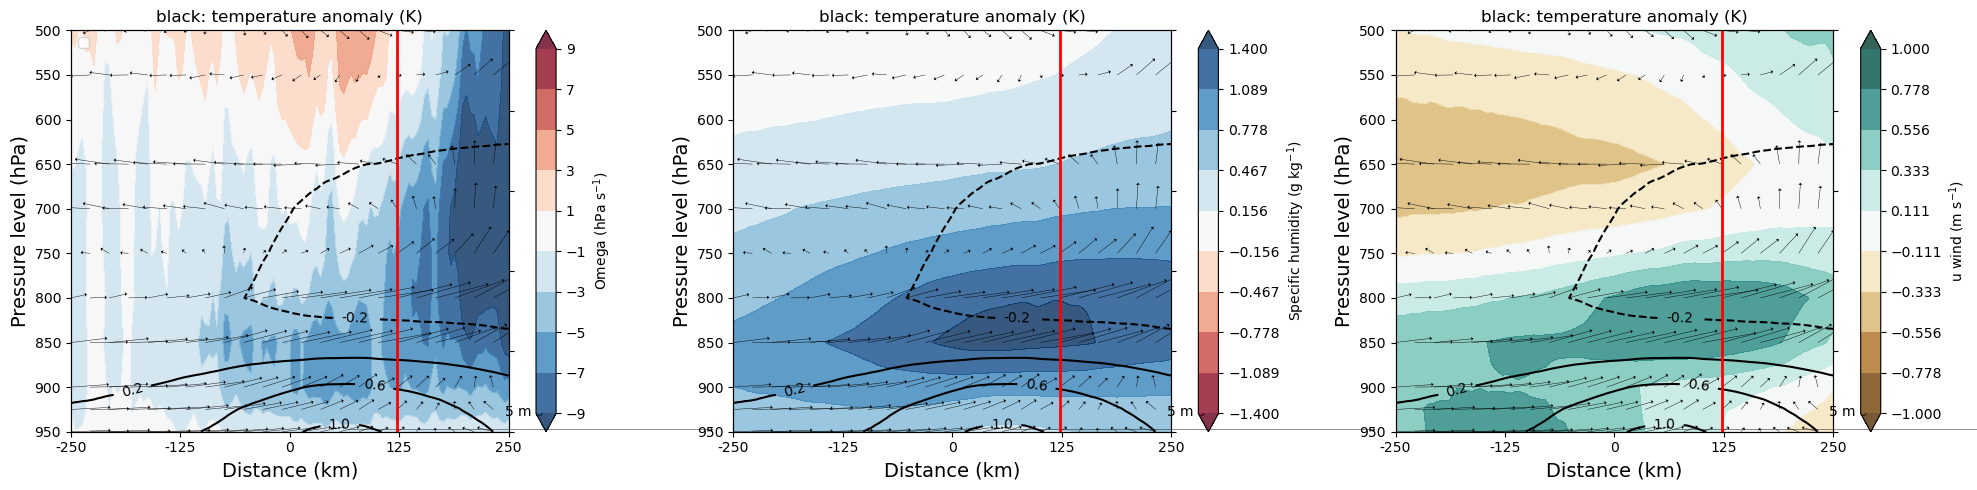

In [11]:
ticks = np.array([-57,-57/2,0,57/2,57])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]

strs='19'
direction='XDIR'

file = 'fut_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'
mean = 'fut_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'

ds = xr.open_dataset(cp4_path+file)
#ds2 = xr.open_dataset(cp4_path+file2)

mean = xr.open_dataset(cp4_path+mean)


from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0

lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.longitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(20,5), dpi=100)

for idx, data in enumerate([ds]): #, ds2

    ax = f.add_subplot(1,3,idx+1)

    mp=ax.contourf(data.longitude, ds.pressure, (data['omega_cross'])*100, cmap='RdBu_r',levels=np.linspace(-9,9,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    plt.colorbar(mp, label='Omega (hPa s$^{-1}$)')
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.longitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # # Set major ticks locator for the y-axis to be every 100 steps
    # ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # # Set minor ticks locator for the y-axis to be every 20 steps
    # ax.yaxis.set_minor_locator(MultipleLocator(20))
    # #ax.set_ylim(980,600)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()
    
    plt.title('', fontsize=14)

    ax.axvline(28, color='r', linewidth='2')
    
    # cbar.label('Relative humidity (%)')
    plt.title('black: temperature anomaly (K)')
    plt.legend(loc='upper left')
    ax2.set_yticklabels([])

    #############################################


for idx, data in enumerate([ds]): #, ds2

    ax = f.add_subplot(1,3,idx+2)

    mp=ax.contourf(data.longitude, ds.pressure, (data['q_cross'])*1000, cmap='RdBu',levels=np.linspace(-1.4,1.4,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    plt.colorbar(mp, label='Specific humidity (g kg$^{-1}$)')
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.longitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # # Set major ticks locator for the y-axis to be every 100 steps
    # ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # # Set minor ticks locator for the y-axis to be every 20 steps
    # ax.yaxis.set_minor_locator(MultipleLocator(20))
    # #ax.set_ylim(980,600)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()
    
    plt.title('', fontsize=14)

    ax.axvline(28, color='r', linewidth='2')
    
    # cbar.label('Relative humidity (%)')
    plt.title('black: temperature anomaly (K)')
    #plt.legend(loc='upper left')
    ax2.set_yticklabels([])


    #########################################


for idx, data in enumerate([ds]): #, ds2

    ax = f.add_subplot(1,3,idx+3)

    #div = calc_div(data)
    # thresh = np.max(np.abs(np.percentile(div, [5, 95])))
    # mp=ax.contourf(div.longitude, div.pressure, div, cmap='RdBu_r',levels=np.linspace(thresh * -1, thresh, 12), alpha=0.8, extend='both') 

    mp=ax.contourf(data.longitude, ds.pressure, (data['u_cross']), cmap='BrBG',levels=np.linspace(-1,1,10), alpha=0.8, extend='both')
    plt.colorbar(mp, label='u wind (m s$^{-1}$)')
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.longitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # # Set major ticks locator for the y-axis to be every 100 steps
    # ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # # Set minor ticks locator for the y-axis to be every 20 steps
    # ax.yaxis.set_minor_locator(MultipleLocator(20))
    # #ax.set_ylim(980,600)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()
    
    plt.title('', fontsize=14)

    ax.axvline(28, color='r', linewidth='2')
    
    # cbar.label('Relative humidity (%)')
    plt.title('black: temperature anomaly (K)')
    #plt.legend(loc='upper left')
    ax2.set_yticklabels([])
    
    plt.tight_layout()

#f.savefig('cross_3hmeans_XDIR_hist.jpg')

/tmp/ipykernel_1119/1823159630.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


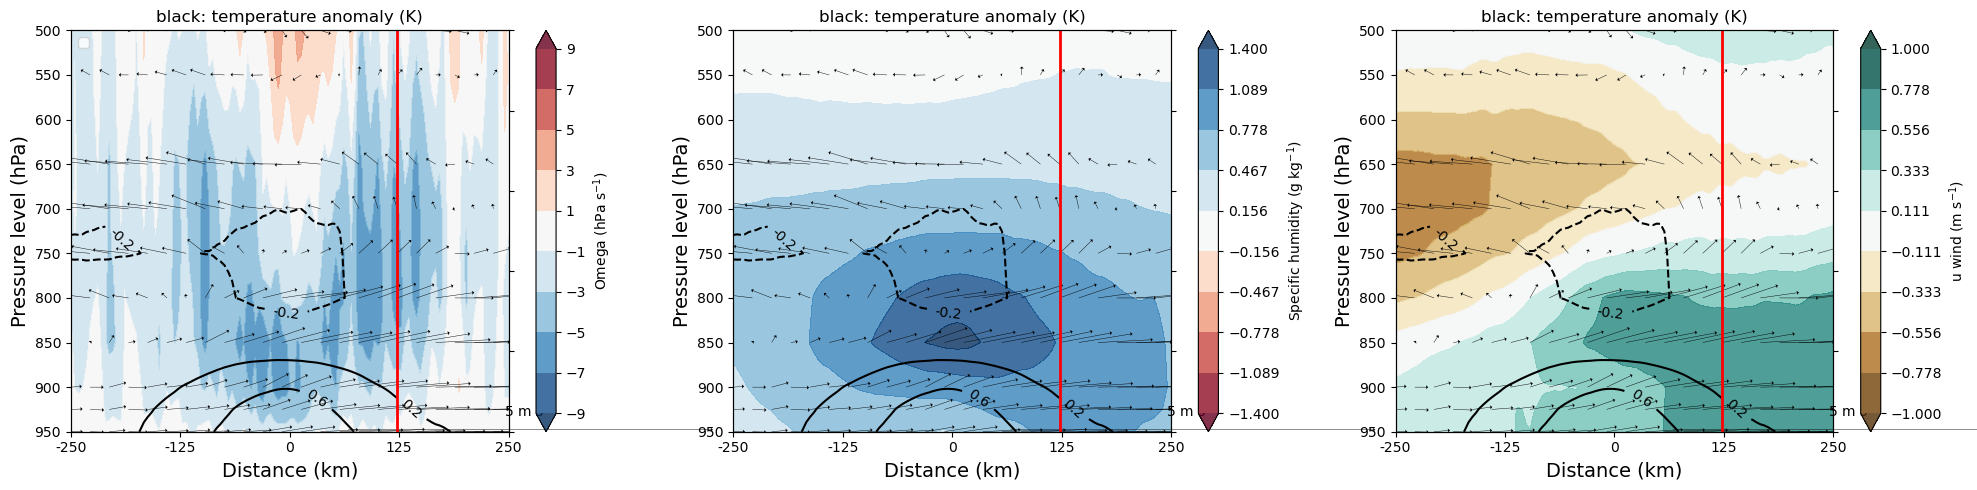

In [35]:
ticks = np.array([-57,-57/2,0,57/2,57])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]

strs='19'
direction='YDIR'


file = 'fut_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'
mean = 'fut_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'

ds = xr.open_dataset(cp4_path+file)
#ds2 = xr.open_dataset(cp4_path+file2)

mean = xr.open_dataset(cp4_path+mean)


from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0

lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.latitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(20,5), dpi=100)

for idx, data in enumerate([ds]): #, ds2

    ax = f.add_subplot(1,3,idx+1)

    mp=ax.contourf(data.latitude, ds.pressure, (data['omega_cross'])*100, cmap='RdBu_r',levels=np.linspace(-9,9,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    plt.colorbar(mp, label='Omega (hPa s$^{-1}$)')
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.latitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # # Set major ticks locator for the y-axis to be every 100 steps
    # ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # # Set minor ticks locator for the y-axis to be every 20 steps
    # ax.yaxis.set_minor_locator(MultipleLocator(20))
    # #ax.set_ylim(980,600)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()
    
    plt.title('', fontsize=14)

    ax.axvline(28, color='r', linewidth='2')
    
    # cbar.label('Relative humidity (%)')
    plt.title('black: temperature anomaly (K)')
    plt.legend(loc='upper left')
    ax2.set_yticklabels([])

    #############################################


for idx, data in enumerate([ds]): #, ds2

    ax = f.add_subplot(1,3,idx+2)

    mp=ax.contourf(data.latitude, ds.pressure, (data['q_cross'])*1000, cmap='RdBu',levels=np.linspace(-1.4,1.4,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    plt.colorbar(mp, label='Specific humidity (g kg$^{-1}$)')
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.latitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # # Set major ticks locator for the y-axis to be every 100 steps
    # ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # # Set minor ticks locator for the y-axis to be every 20 steps
    # ax.yaxis.set_minor_locator(MultipleLocator(20))
    # #ax.set_ylim(980,600)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()
    
    plt.title('', fontsize=14)

    ax.axvline(28, color='r', linewidth='2')
    
    # cbar.label('Relative humidity (%)')
    plt.title('black: temperature anomaly (K)')
    #plt.legend(loc='upper left')
    ax2.set_yticklabels([])


    #########################################


for idx, data in enumerate([ds]): #, ds2

    ax = f.add_subplot(1,3,idx+3)

    #div = calc_div(data)
    # thresh = np.max(np.abs(np.percentile(div, [5, 95])))
    # mp=ax.contourf(div.longitude, div.pressure, div, cmap='RdBu_r',levels=np.linspace(thresh * -1, thresh, 12), alpha=0.8, extend='both') 

    mp=ax.contourf(data.latitude, ds.pressure, (data['u_cross']), cmap='BrBG',levels=np.linspace(-1,1,10), alpha=0.8, extend='both')
    plt.colorbar(mp, label='u wind (m s$^{-1}$)')
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.latitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # # Set major ticks locator for the y-axis to be every 100 steps
    # ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # # Set minor ticks locator for the y-axis to be every 20 steps
    # ax.yaxis.set_minor_locator(MultipleLocator(20))
    # #ax.set_ylim(980,600)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()
    
    plt.title('', fontsize=14)

    ax.axvline(28, color='r', linewidth='2')
    
    # cbar.label('Relative humidity (%)')
    plt.title('black: temperature anomaly (K)')
    #plt.legend(loc='upper left')
    ax2.set_yticklabels([])
    
    plt.tight_layout()

#f.savefig('cross_3hmeans_XDIR_hist.jpg')

<xarray.DataArray 'pblH' ()> Size: 8B
array(1166.73630857)


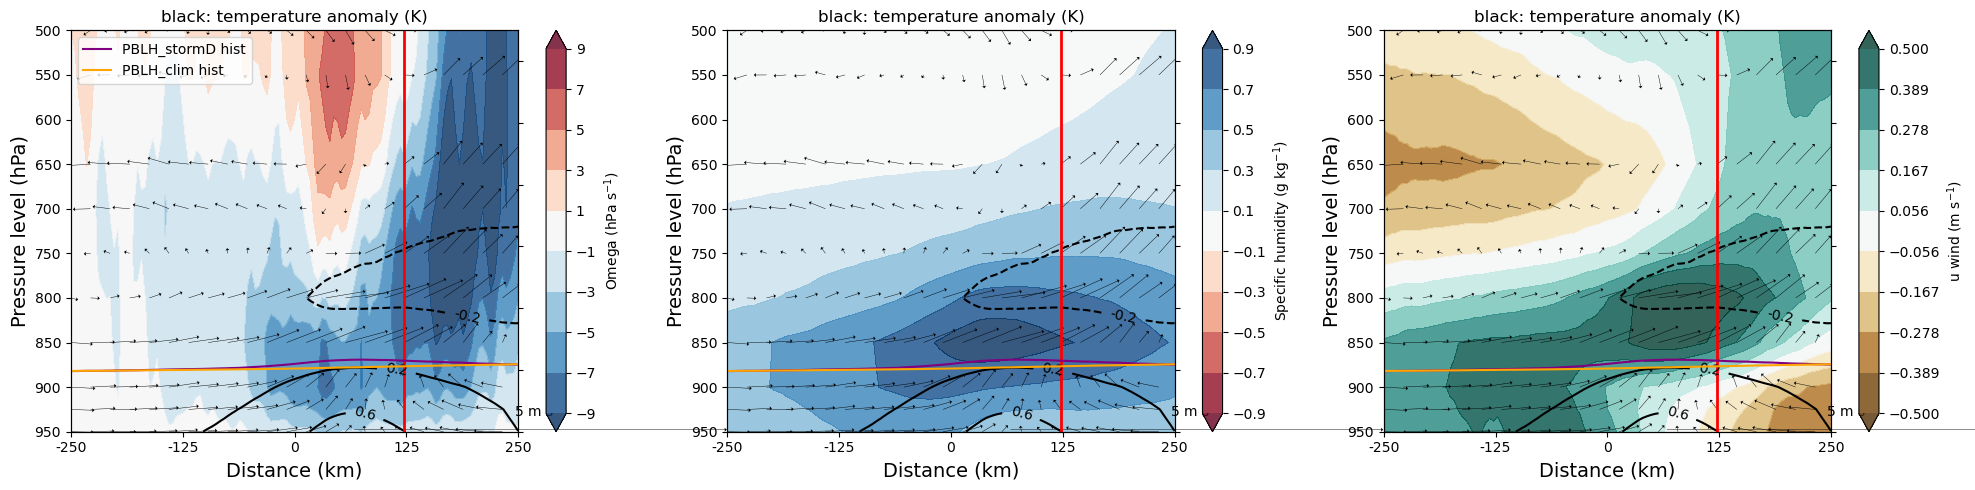

In [37]:
ticks = np.array([-57,-57/2,0,57/2,57])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]

strs='17'
direction='XDIR'

merged_hist, merged_hist_mean = get_anom_and_mean(
    period='hist',
    direction=direction,
    strs=strs
)

merged_fut, merged_fut_mean = get_anom_and_mean(
    period='fut',
    direction=direction,
    strs=strs
)

file = 'hist_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'
mean = 'hist_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'

ds = xr.open_dataset(cp4_path+file)
#ds2 = xr.open_dataset(cp4_path+file2)

mean = xr.open_dataset(cp4_path+mean)


from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0

lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.longitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(20,5), dpi=100)

for idx, data in enumerate([ds]): #, ds2

    ax = f.add_subplot(1,3,idx+1)

    mp=ax.contourf(data.longitude, ds.pressure, (data['omega_cross'])*100, cmap='RdBu_r',levels=np.linspace(-9,9,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    plt.colorbar(mp, label='Omega (hPa s$^{-1}$)')
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.longitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # # Set major ticks locator for the y-axis to be every 100 steps
    # ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # # Set minor ticks locator for the y-axis to be every 20 steps
    # ax.yaxis.set_minor_locator(MultipleLocator(20))
    # #ax.set_ylim(980,600)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(data.longitude, mean['pblH'], label='PBLH_stormD hist', color='purple')
        ax2.plot(data.longitude, mean['pblH']-ds['pblH'], label='PBLH_clim hist', color='orange')

    print(mean['pblH'].max())
    # else:
    #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    ax2.set_ylim(0,6500)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)

    ax.axvline(28, color='r', linewidth='2')
    
    # cbar.label('Relative humidity (%)')
    plt.title('black: temperature anomaly (K)')
    plt.legend(loc='upper left')
    ax2.set_yticklabels([])

    #############################################


for idx, data in enumerate([ds]): #, ds2

    ax = f.add_subplot(1,3,idx+2)

    mp=ax.contourf(data.longitude, ds.pressure, (data['q_cross'])*1000, cmap='RdBu',levels=np.linspace(-0.9,0.9,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    plt.colorbar(mp, label='Specific humidity (g kg$^{-1}$)')
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.longitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # # Set major ticks locator for the y-axis to be every 100 steps
    # ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # # Set minor ticks locator for the y-axis to be every 20 steps
    # ax.yaxis.set_minor_locator(MultipleLocator(20))
    # #ax.set_ylim(980,600)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(data.longitude, mean['pblH'], label='PBLH_stormD hist', color='purple')
        ax2.plot(data.longitude, mean['pblH']-ds['pblH'], label='PBLH_clim hist', color='orange')
    # else:
    #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    ax2.set_ylim(0,6500)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)

    ax.axvline(28, color='r', linewidth='2')
    
    # cbar.label('Relative humidity (%)')
    plt.title('black: temperature anomaly (K)')
    #plt.legend(loc='upper left')
    ax2.set_yticklabels([])


    #########################################


for idx, data in enumerate([ds]): #, ds2

    ax = f.add_subplot(1,3,idx+3)

    #div = calc_div(data)
    # thresh = np.max(np.abs(np.percentile(div, [5, 95])))
    # mp=ax.contourf(div.longitude, div.pressure, div, cmap='RdBu_r',levels=np.linspace(thresh * -1, thresh, 12), alpha=0.8, extend='both') 

    mp=ax.contourf(data.longitude, ds.pressure, (data['u_cross']), cmap='BrBG',levels=np.linspace(-0.5,0.5,10), alpha=0.8, extend='both')
    plt.colorbar(mp, label='u wind (m s$^{-1}$)')
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.longitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # # Set major ticks locator for the y-axis to be every 100 steps
    # ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # # Set minor ticks locator for the y-axis to be every 20 steps
    # ax.yaxis.set_minor_locator(MultipleLocator(20))
    # #ax.set_ylim(980,600)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(data.longitude, mean['pblH'], label='PBLH_stormD hist', color='purple')
        ax2.plot(data.longitude, mean['pblH']-ds['pblH'], label='PBLH_clim hist', color='orange')
    # else:
    #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    ax2.set_ylim(0,6500)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)

    ax.axvline(28, color='r', linewidth='2')
    
    # cbar.label('Relative humidity (%)')
    plt.title('black: temperature anomaly (K)')
    #plt.legend(loc='upper left')
    ax2.set_yticklabels([])
    
    plt.tight_layout()

#f.savefig('cross_3hmeans_XDIR_hist.jpg')

<xarray.DataArray 'pblH' ()> Size: 8B
array(1319.15706331)


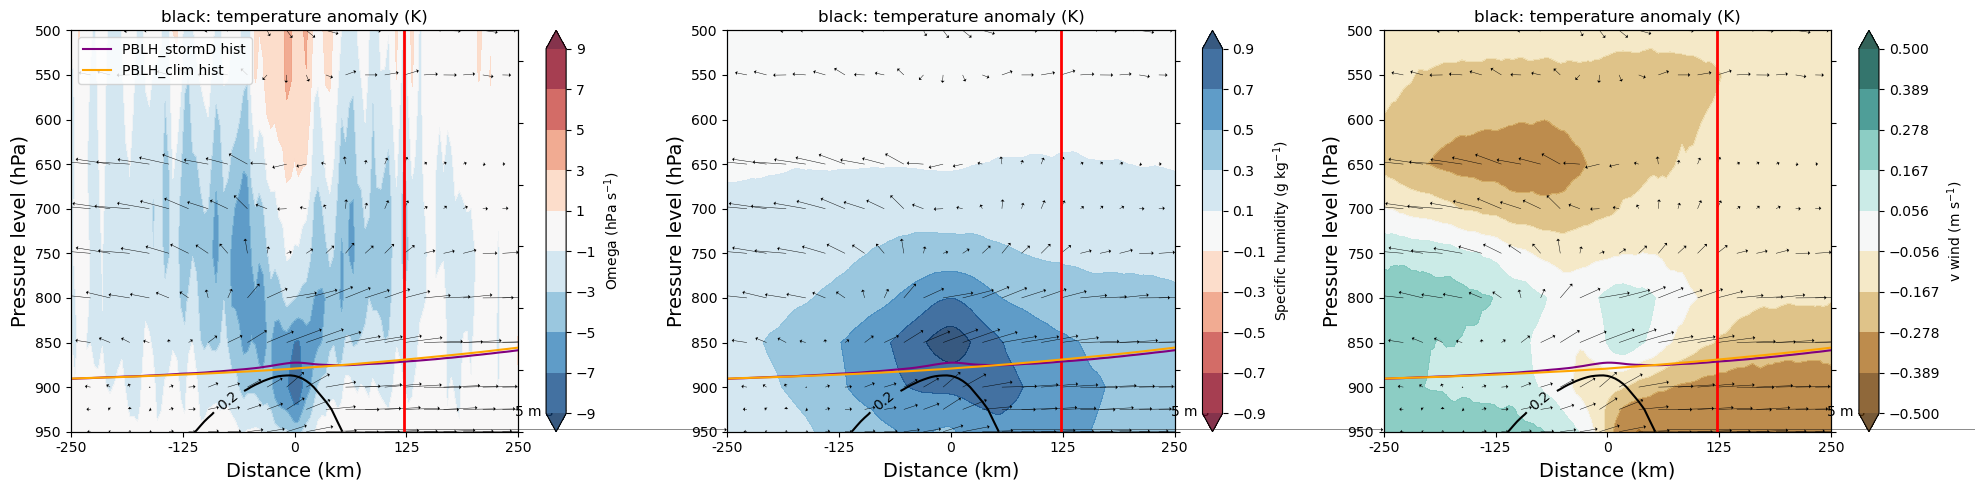

In [13]:
ticks = np.array([-57,-57/2,0,57/2,57])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]

strs='17'
direction='YDIR'
merged_hist, merged_fut, merged_hist_mean, merged_fut_mean = get_anom_and_mean(direction='YDIR', strs=strs)
file = 'hist_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'
mean = 'hist_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'

ds = xr.open_dataset(cp4_path+file)
#ds2 = xr.open_dataset(cp4_path+file2)

mean = xr.open_dataset(cp4_path+mean)


from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0

lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.latitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(20,5), dpi=100)

for idx, data in enumerate([ds]): #, ds2

    ax = f.add_subplot(1,3,idx+1)

    mp=ax.contourf(data.latitude, ds.pressure, (data['omega_cross'])*100, cmap='RdBu_r',levels=np.linspace(-9,9,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    plt.colorbar(mp, label='Omega (hPa s$^{-1}$)')
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.latitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # # Set major ticks locator for the y-axis to be every 100 steps
    # ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # # Set minor ticks locator for the y-axis to be every 20 steps
    # ax.yaxis.set_minor_locator(MultipleLocator(20))
    # #ax.set_ylim(980,600)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(data.latitude, mean['pblH'], label='PBLH_stormD hist', color='purple')
        ax2.plot(data.latitude, mean['pblH']-ds['pblH'], label='PBLH_clim hist', color='orange')

    print(mean['pblH'].max())
    # else:
    #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    ax2.set_ylim(0,6500)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)

    ax.axvline(28, color='r', linewidth='2')
    
    # cbar.label('Relative humidity (%)')
    plt.title('black: temperature anomaly (K)')
    plt.legend(loc='upper left')
    ax2.set_yticklabels([])

    #############################################


for idx, data in enumerate([ds]): #, ds2

    ax = f.add_subplot(1,3,idx+2)

    mp=ax.contourf(data.latitude, ds.pressure, (data['q_cross'])*1000, cmap='RdBu',levels=np.linspace(-0.9,0.9,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    plt.colorbar(mp, label='Specific humidity (g kg$^{-1}$)')
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.latitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # # Set major ticks locator for the y-axis to be every 100 steps
    # ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # # Set minor ticks locator for the y-axis to be every 20 steps
    # ax.yaxis.set_minor_locator(MultipleLocator(20))
    # #ax.set_ylim(980,600)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(data.latitude, mean['pblH'], label='PBLH_stormD hist', color='purple')
        ax2.plot(data.latitude, mean['pblH']-ds['pblH'], label='PBLH_clim hist', color='orange')
    # else:
    #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    ax2.set_ylim(0,6500)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)

    ax.axvline(28, color='r', linewidth='2')
    
    # cbar.label('Relative humidity (%)')
    plt.title('black: temperature anomaly (K)')
    #plt.legend(loc='upper left')
    ax2.set_yticklabels([])


    #########################################


for idx, data in enumerate([ds]): #, ds2

    ax = f.add_subplot(1,3,idx+3)

    #div = calc_div(data)
    # thresh = np.max(np.abs(np.percentile(div, [5, 95])))
    # mp=ax.contourf(div.longitude, div.pressure, div, cmap='RdBu_r',levels=np.linspace(thresh * -1, thresh, 12), alpha=0.8, extend='both') 

    mp=ax.contourf(data.latitude, ds.pressure, (data['v_cross']), cmap='BrBG',levels=np.linspace(-0.5,0.5,10), alpha=0.8, extend='both')
    plt.colorbar(mp, label='v wind (m s$^{-1}$)')
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.latitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # # Set major ticks locator for the y-axis to be every 100 steps
    # ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # # Set minor ticks locator for the y-axis to be every 20 steps
    # ax.yaxis.set_minor_locator(MultipleLocator(20))
    # #ax.set_ylim(980,600)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(data.latitude, mean['pblH'], label='PBLH_stormD hist', color='purple')
        ax2.plot(data.latitude, mean['pblH']-ds['pblH'], label='PBLH_clim hist', color='orange')
    # else:
    #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    ax2.set_ylim(0,6500)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)

    ax.axvline(28, color='r', linewidth='2')
    
    # cbar.label('Relative humidity (%)')
    plt.title('black: temperature anomaly (K)')
    #plt.legend(loc='upper left')
    ax2.set_yticklabels([])
    
    plt.tight_layout()

#f.savefig('cross_3hmeans_YDIR_hist.jpg')

/tmp/ipykernel_3633/3317437012.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_3633/3317437012.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3633/3317437012.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


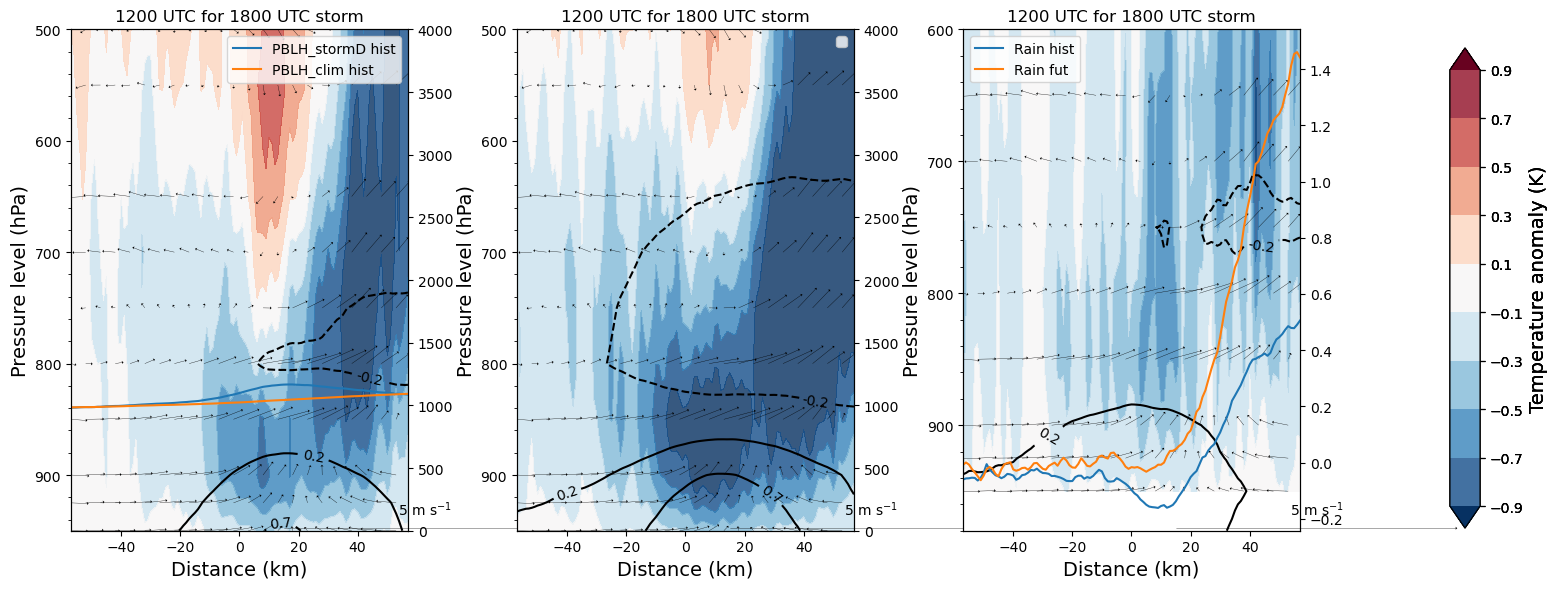

In [12]:
strs='17'
direction='XDIR'
#merged_hist, merged_fut, merged_hist_mean, merged_fut_mean = get_anom_and_mean(direction='XDIR', strs=strs)
file = 'hist_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'
file2 = 'fut_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'

mean = 'hist_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'
mean2 = 'fut_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'
    
ds = xr.open_dataset(cp4_path+file)
ds2 = xr.open_dataset(cp4_path+file2)

mean = xr.open_dataset(cp4_path+mean)
mean2 = xr.open_dataset(cp4_path+mean2)
clim_hist = mean-ds
clim_fut = mean2-ds2


from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0

lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.longitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(15,6), dpi=100)

for idx, data in enumerate([ds, ds2]):

    ax = f.add_subplot(1,3,idx+1)

    mp=ax.contourf(data.longitude, ds.pressure, (data['omega_cross'])*10, cmap='RdBu_r',levels=np.linspace(-0.9,0.9,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.longitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # Set major ticks locator for the y-axis to be every 100 steps
    ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # Set minor ticks locator for the y-axis to be every 20 steps
    ax.yaxis.set_minor_locator(MultipleLocator(20))
    #ax.set_ylim(980,600)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(data.longitude, mean['pblH'], label='PBLH_stormD hist')
        ax2.plot(data.longitude, mean['pblH']-ds['pblH'], label='PBLH_clim hist')
    # else:
    #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    ax2.set_ylim(0,4000)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)
    
    # cbar.label('Relative humidity (%)')
    plt.title('1200 UTC for 1800 UTC storm')
    plt.legend()
    
    plt.tight_layout()
    f.subplots_adjust(right=0.87)
    cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
    cbar = f.colorbar(mp, cax)
    cbar.set_label('Temperature anomaly (K)', fontsize=14)


ax = f.add_subplot(1,3,3)

mp=ax.contourf(data.longitude, ds.pressure, (ds2['omega_cross']-ds['omega_cross'])*10, cmap='RdBu_r',levels=np.linspace(-0.9,0.9,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 

qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')

num = ax.contour(data.longitude, merged_hist.pressure, (merged_fut['t_cross']-merged_hist['t_cross']), colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')

# Set major ticks locator for the y-axis to be every 100 steps
ax.yaxis.set_major_locator(MultipleLocator(100))

# Set minor ticks locator for the y-axis to be every 20 steps
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(980,600)

ax.set_xlabel('Distance (km)', fontsize=14)
ax.set_ylabel('Pressure level (hPa)', fontsize=14)

ax2 = ax.twinx()
ax2.plot(data.longitude, ds['lsRain_noon']-clim_hist['lsRain_noon'], label='Rain hist')
ax2.plot(data.longitude, ds2['lsRain_noon']-clim_fut['lsRain_noon'], label='Rain fut')

plt.title('', fontsize=14)

# cbar.label('Relative humidity (%)')
plt.title('1200 UTC for 1800 UTC storm')
plt.legend()

plt.tight_layout()
f.subplots_adjust(right=0.87)
cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
cbar = f.colorbar(mp, cax)
cbar.set_label('Temperature anomaly (K)', fontsize=14)


#f.savefig('cross_17hstorms_xdir.jpg')

/tmp/ipykernel_1119/4178068100.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_1119/4178068100.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1119/4178068100.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


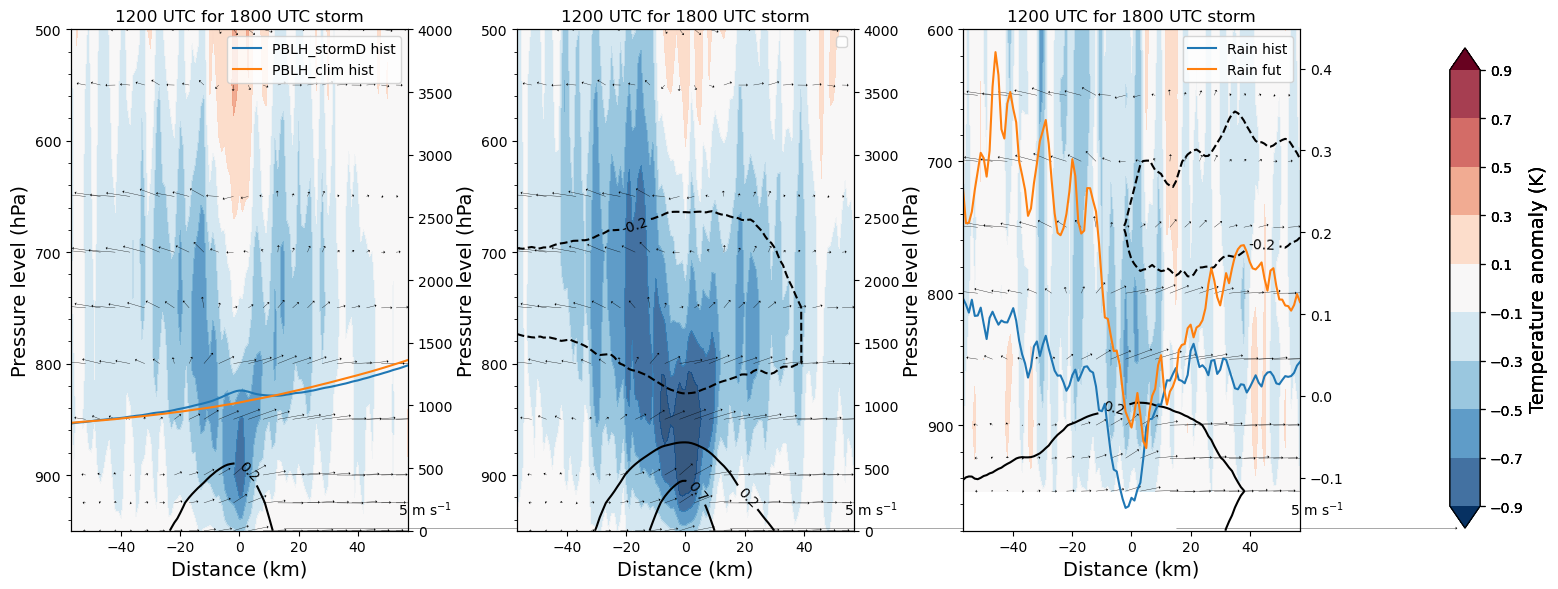

In [40]:
strs='17'
direction='YDIR'
#merged_hist, merged_fut, merged_hist_mean, merged_fut_mean = get_anom_and_mean(direction='XDIR', strs=strs)
file = 'hist_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'
file2 = 'fut_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'

mean = 'hist_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'
mean2 = 'fut_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'
    
ds = xr.open_dataset(cp4_path+file)
ds2 = xr.open_dataset(cp4_path+file2)

mean = xr.open_dataset(cp4_path+mean)
mean2 = xr.open_dataset(cp4_path+mean2)
clim_hist = mean-ds
clim_fut = mean2-ds2


from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0

lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.latitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(15,6), dpi=100)

for idx, data in enumerate([ds, ds2]):

    ax = f.add_subplot(1,3,idx+1)

    mp=ax.contourf(data.latitude, ds.pressure, (data['omega_cross'])*10, cmap='RdBu_r',levels=np.linspace(-0.9,0.9,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.latitude, ds.pressure, (data['t_cross']), colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # Set major ticks locator for the y-axis to be every 100 steps
    ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # Set minor ticks locator for the y-axis to be every 20 steps
    ax.yaxis.set_minor_locator(MultipleLocator(20))
    #ax.set_ylim(980,600)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(data.latitude, mean['pblH'], label='PBLH_stormD hist')
        ax2.plot(data.latitude, mean['pblH']-ds['pblH'], label='PBLH_clim hist')
    # else:
    #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    ax2.set_ylim(0,4000)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)
    
    # cbar.label('Relative humidity (%)')
    plt.title('1200 UTC for 1800 UTC storm')
    plt.legend()
    
    plt.tight_layout()
    f.subplots_adjust(right=0.87)
    cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
    cbar = f.colorbar(mp, cax)
    cbar.set_label('Temperature anomaly (K)', fontsize=14)


ax = f.add_subplot(1,3,3)

mp=ax.contourf(data.latitude, ds.pressure, (ds2['omega_cross']-ds['omega_cross'])*10, cmap='RdBu_r',levels=np.linspace(-0.9,0.9,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 

qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')

num = ax.contour(data.latitude, merged_hist.pressure, (merged_fut['t_cross']-merged_hist['t_cross']), colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')

# Set major ticks locator for the y-axis to be every 100 steps
ax.yaxis.set_major_locator(MultipleLocator(100))

# Set minor ticks locator for the y-axis to be every 20 steps
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(980,600)

ax.set_xlabel('Distance (km)', fontsize=14)
ax.set_ylabel('Pressure level (hPa)', fontsize=14)

ax2 = ax.twinx()
ax2.plot(data.latitude, ds['lsRain_noon']-clim_hist['lsRain_noon'], label='Rain hist')
ax2.plot(data.latitude, ds2['lsRain_noon']-clim_fut['lsRain_noon'], label='Rain fut')

plt.title('', fontsize=14)

# cbar.label('Relative humidity (%)')
plt.title('1200 UTC for 1800 UTC storm')
plt.legend()

plt.tight_layout()
f.subplots_adjust(right=0.87)
cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
cbar = f.colorbar(mp, cax)
cbar.set_label('Temperature anomaly (K)', fontsize=14)


#f.savefig('cross_17hstorms_xdir.jpg')

In [78]:
(data['t_cross'])

<xarray.DataArray 't_cross' (pressure: 11, latitude: 115)> Size: 10kB
array([[305.98379187, 306.01441834, 306.04681502, ..., 310.42455632,
        310.47536353, 310.52422252],
       [303.82525635, 303.86730957, 303.90325928, ..., 308.39993286,
        308.45281982, 308.50042725],
       [301.87261963, 301.9005127 , 301.93011475, ..., 306.36474609,
        306.41732788, 306.46862793],
       ...,
       [284.59689331, 284.60528564, 284.61355591, ..., 285.66165161,
        285.67294312, 285.68411255],
       [276.37692261, 276.37554932, 276.37487793, ..., 276.28149414,
        276.28170776, 276.28097534],
       [272.39242554, 272.38973999, 272.38595581, ..., 272.08380127,
        272.08126831, 272.07858276]], shape=(11, 115))
Coordinates:
  * pressure  (pressure) float64 88B 980.0 950.0 925.0 ... 650.0 550.0 500.0
  * latitude  (latitude) int64 920B -57 -56 -55 -54 -53 -52 ... 53 54 55 56 57

/tmp/ipykernel_1119/3238874543.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_1119/3238874543.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1119/3238874543.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


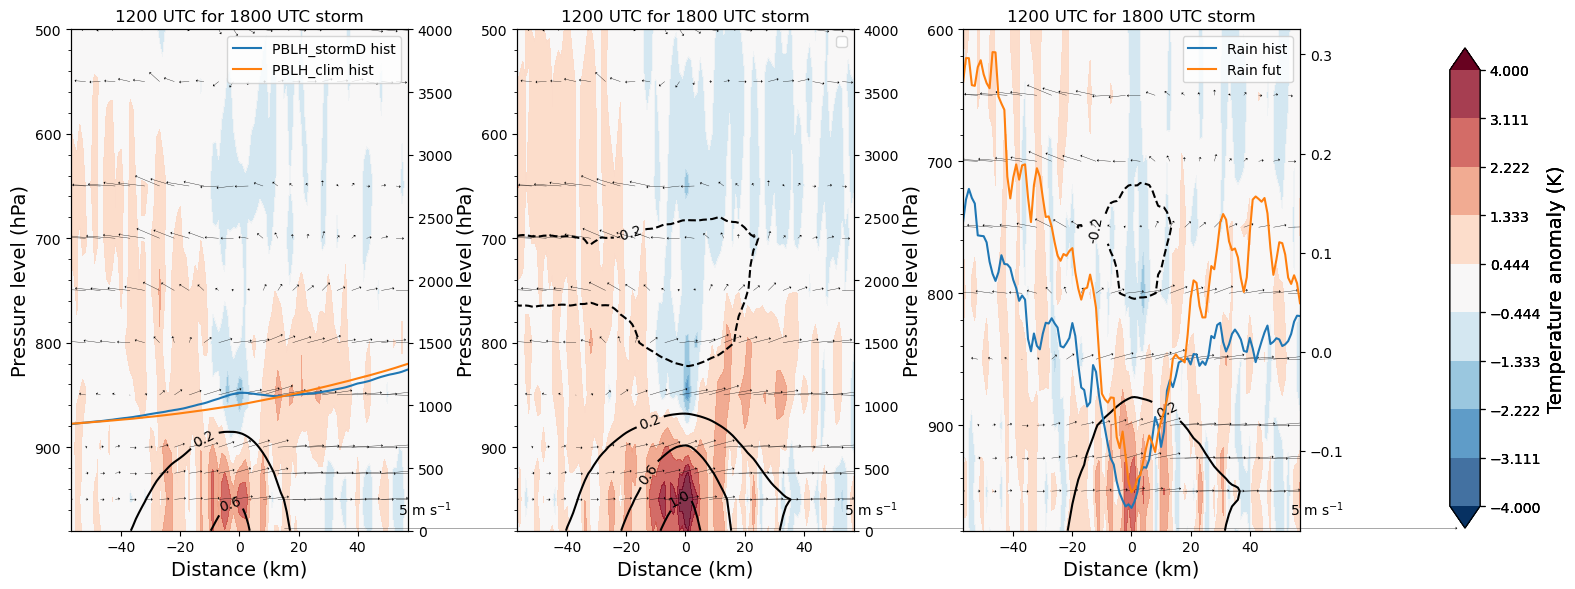

In [85]:
strs='18'
direction='YDIR'

if direction == 'XDIR':
    xdim='longitude'
    u_name = 'u_cross'
else:
    xdim='latitude'
    u_name = 'v_cross'

merged_hist, merged_hist_mean = get_anom_and_mean(
    period='hist',
    direction=direction,
    strs=strs
)

merged_fut, merged_fut_mean = get_anom_and_mean(
    period='fut',
    direction=direction,
    strs=strs
)


file = 'hist_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'
file2 = 'fut_anom_Jul-Sep_'+strs+'h_'+direction+'.nc'

mean = 'hist_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'
mean2 = 'fut_mean_Jul-Sep_'+strs+'h_'+direction+'.nc'
    
ds = xr.open_dataset(cp4_path+file)
ds2 = xr.open_dataset(cp4_path+file2)

mean = xr.open_dataset(cp4_path+mean)
mean2 = xr.open_dataset(cp4_path+mean2)
clim_hist = mean-ds
clim_fut = mean2-ds2


from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0

lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross[xdim][sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(15,6), dpi=100)
divs = []
for idx, data in enumerate([merged_hist, merged_fut]):

    div = cross_section_divergence_or_convergence(
    data,
    direction=direction,
    u_name=u_name,
    x_dim=xdim,
    coord_units="km",
    latitude_for_lon=10.0,   # representative latitude of the section
)
    divs.append(div)
    ax = f.add_subplot(1,3,idx+1)

    mp=ax.contourf(data[xdim], data.pressure, div*1e5, cmap='RdBu_r',levels=np.linspace(-4,4,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data[xdim], data.pressure, (data['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # Set major ticks locator for the y-axis to be every 100 steps
    ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # Set minor ticks locator for the y-axis to be every 20 steps
    ax.yaxis.set_minor_locator(MultipleLocator(20))
    #ax.set_ylim(980,600)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(data[xdim], mean['pblH'], label='PBLH_stormD hist')
        ax2.plot(data[xdim], mean['pblH']-ds['pblH'], label='PBLH_clim hist')
    # else:
    #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    ax2.set_ylim(0,4000)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)
    
    # cbar.label('Relative humidity (%)')
    plt.title('1200 UTC for 1800 UTC storm')
    plt.legend()
    
    plt.tight_layout()
    f.subplots_adjust(right=0.87)
    cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
    cbar = f.colorbar(mp, cax)
    cbar.set_label('Temperature anomaly (K)', fontsize=14)


ax = f.add_subplot(1,3,3)

mp=ax.contourf(data[xdim], data.pressure, (divs[1]-divs[0])*1e5, cmap='RdBu_r',levels=np.linspace(-4,4,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 

qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')

num = ax.contour(data[xdim], merged_hist.pressure, (merged_fut['t_cross']-merged_hist['t_cross']), colors='k',levels=np.linspace(-1.8,1.8,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')

# Set major ticks locator for the y-axis to be every 100 steps
ax.yaxis.set_major_locator(MultipleLocator(100))

# Set minor ticks locator for the y-axis to be every 20 steps
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(980,600)

ax.set_xlabel('Distance (km)', fontsize=14)
ax.set_ylabel('Pressure level (hPa)', fontsize=14)

ax2 = ax.twinx()
ax2.plot(data[xdim], ds['lsRain_noon']-clim_hist['lsRain_noon'], label='Rain hist')
ax2.plot(data[xdim], ds2['lsRain_noon']-clim_fut['lsRain_noon'], label='Rain fut')

plt.title('', fontsize=14)

# cbar.label('Relative humidity (%)')
plt.title('1200 UTC for '+strs+'00 UTC storm')
plt.legend()

plt.tight_layout()
f.subplots_adjust(right=0.87)
cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
cbar = f.colorbar(mp, cax)
cbar.set_label('Temperature anomaly (K)', fontsize=14)


#f.savefig('cross_17hstorms_xdir.jpg')

[Text(-57.0, 0, '-250'),
 Text(-28.5, 0, '-125'),
 Text(0.0, 0, '0'),
 Text(28.5, 0, '125'),
 Text(57.0, 0, '250')]

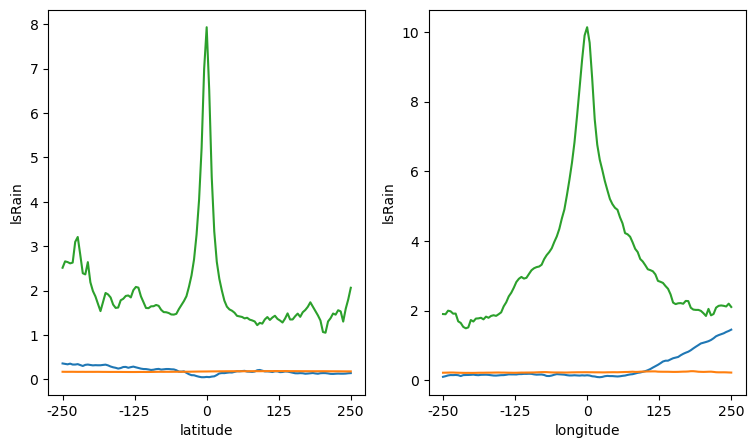

In [72]:
ticks = np.array([-57,-57/2,0,57/2,57])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]

f = plt.figure(figsize=(9,5))
ax = f.add_subplot(121)
ds['lsRain_noon'].plot()
clim_hist['lsRain_noon'].plot()
ds['lsRain'].plot()
ax.set_xticks(ticks)
ax.set_xticklabels(labels)

ax = f.add_subplot(122)
ds2['lsRain_noon'].plot()
clim_fut['lsRain_noon'].plot()
ds2['lsRain'].plot()
ax.set_xticks(ticks)
ax.set_xticklabels(labels)

[Text(-57.0, 0, '-250'),
 Text(-28.5, 0, '-125'),
 Text(0.0, 0, '0'),
 Text(28.5, 0, '125'),
 Text(57.0, 0, '250')]

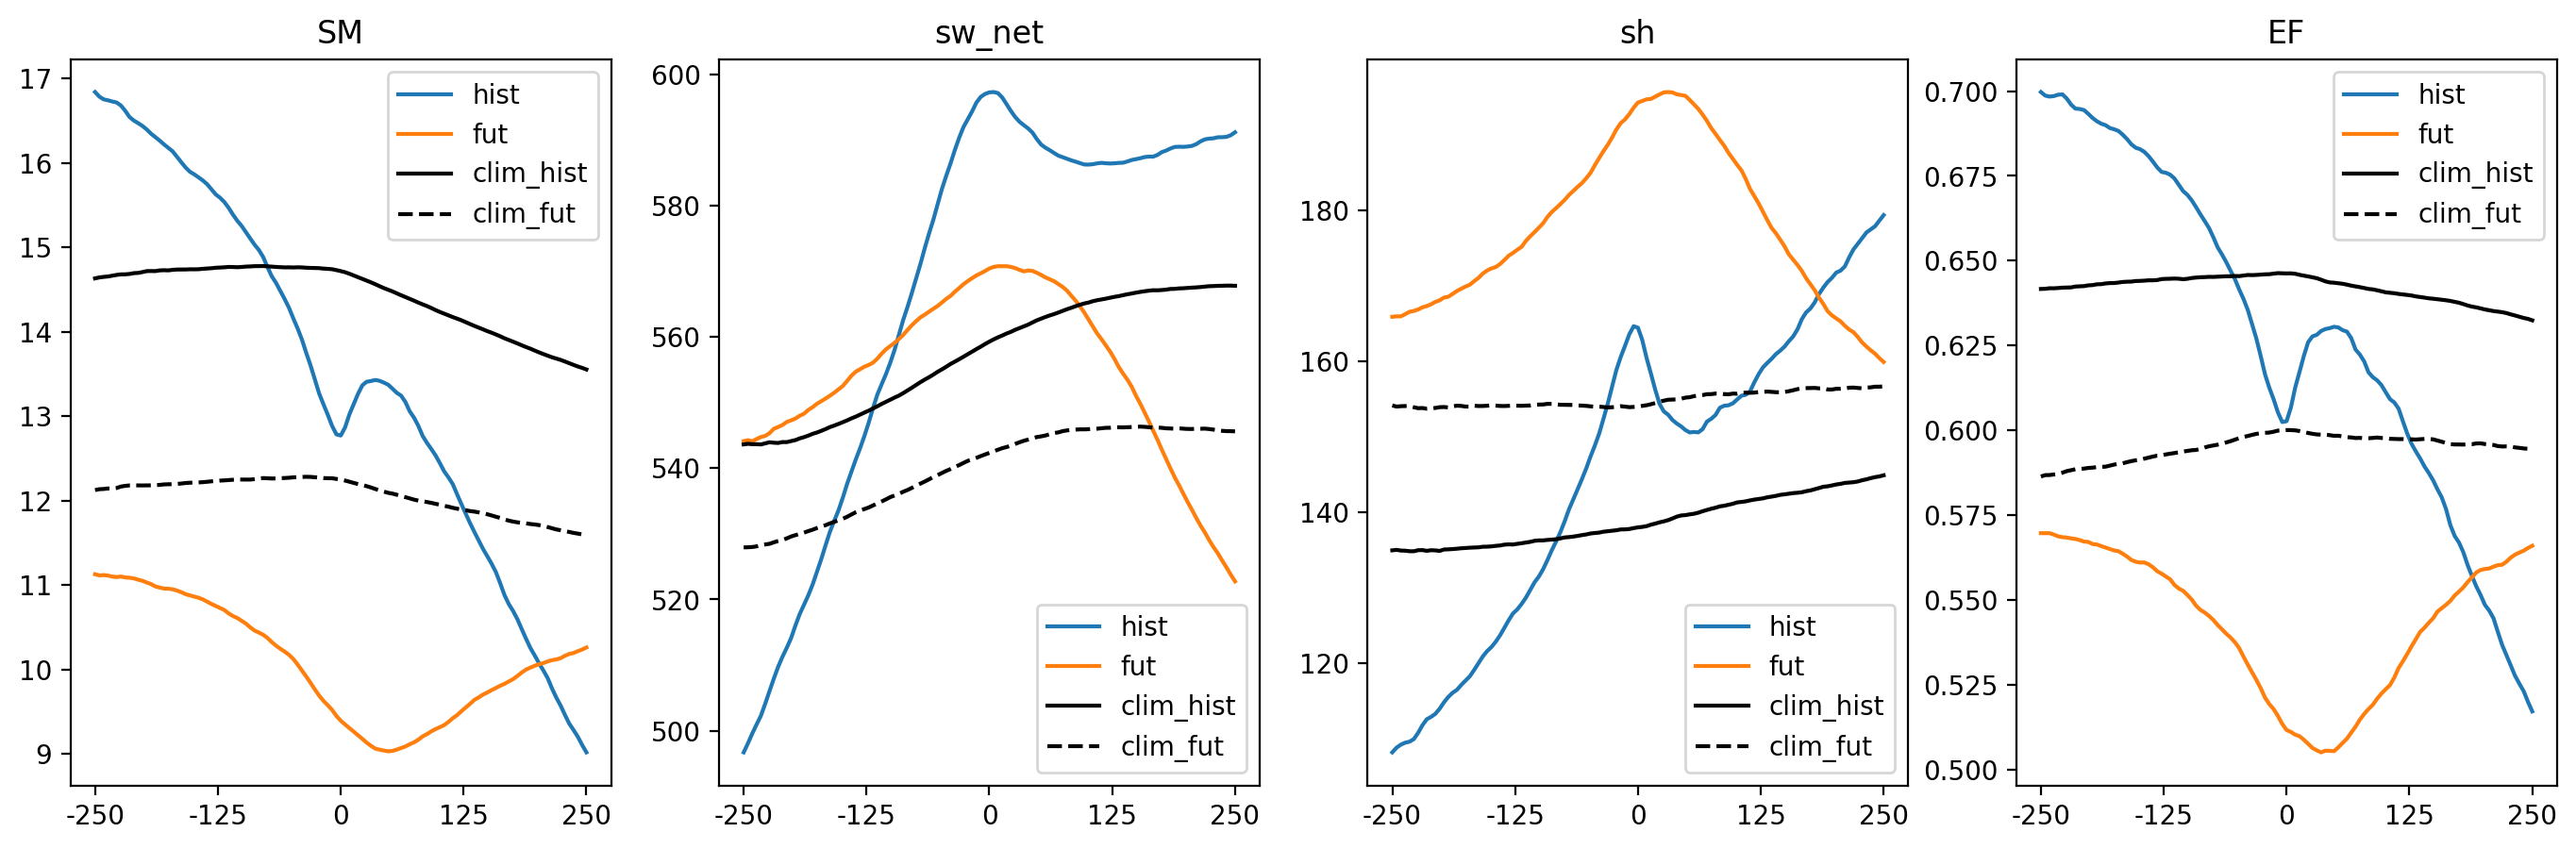

In [75]:
# ticks = np.array([-57,-57/2,0,57/2,57])
# #labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
# labels = [-250,-125,0,125,250]

xvar = mean.latitude

f = plt.figure(figsize=(17,5), dpi=200)
ax = f.add_subplot(141)

var='SM'

ax.plot(xvar, mean[var], label='hist')
ax.plot(xvar, mean2[var], label='fut')
ax.plot(xvar, clim_hist[var], label='clim_hist', color='k')
ax.plot(xvar, clim_fut[var], label='clim_fut', color='k', linestyle='dashed')
ax.legend()
plt.title(var)

ax.set_xticks(ticks)
ax.set_xticklabels(labels)



ax = f.add_subplot(142)

var = 'sw_net'
ax.plot(xvar, mean[var], label='hist')
ax.plot(xvar, mean2[var], label='fut')
ax.plot(xvar, clim_hist[var], label='clim_hist', color='k')
ax.plot(xvar, clim_fut[var], label='clim_fut', color='k', linestyle='dashed')
ax.legend()
plt.title(var)
ax.set_xticks(ticks)
ax.set_xticklabels(labels)

ax = f.add_subplot(143)

var = 'sh'
ax.plot(xvar, mean[var], label='hist')
ax.plot(xvar, mean2[var], label='fut')
ax.plot(xvar, clim_hist[var], label='clim_hist', color='k')
ax.plot(xvar, clim_fut[var], label='clim_fut', color='k', linestyle='dashed')
ax.legend()
plt.title(var)

ax.set_xticks(ticks)
ax.set_xticklabels(labels)

ax = f.add_subplot(144)

var = 'EF'
ax.plot(xvar, mean['lh']/(mean['lh']+mean['sh']), label='hist')
ax.plot(xvar, mean2['lh']/(mean2['lh']+mean2['sh']), label='fut')
ax.plot(xvar, clim_hist['lh']/(clim_hist['lh']+clim_hist['sh']), label='clim_hist', color='k')
ax.plot(xvar, clim_fut['lh']/(clim_fut['lh']+clim_fut['sh']), label='clim_fut', color='k', linestyle='dashed')
ax.legend()
plt.title(var)

ax.set_xticks(ticks)
ax.set_xticklabels(labels)

In [65]:
mean

<xarray.Dataset>
Dimensions:         (longitude: 115, pressure: 10)
Coordinates:
  * longitude       (longitude) int64 -57 -56 -55 -54 -53 -52 ... 53 54 55 56 57
  * pressure        (pressure) float32 950.0 925.0 900.0 ... 650.0 550.0 500.0
Data variables: (12/24)
    lw_out_PBLtop   (longitude) float64 ...
    lsRain          (longitude) float64 ...
    lh              (longitude) float64 ...
    sh              (longitude) float64 138.4 138.6 138.4 ... 146.4 146.0 145.6
    lw_net          (longitude) float64 ...
    sw_net          (longitude) float64 559.0 559.3 559.4 ... 559.0 557.9 556.7
    ...              ...
    omega_cross     (pressure, longitude) float32 ...
    v_cross_ST      (pressure, longitude) float32 ...
    q_cross_ST      (pressure, longitude) float32 ...
    t_cross_ST      (pressure, longitude) float32 ...
    u_cross_ST      (pressure, longitude) float32 ...
    omega_cross_ST  (pressure, longitude) float32 ...

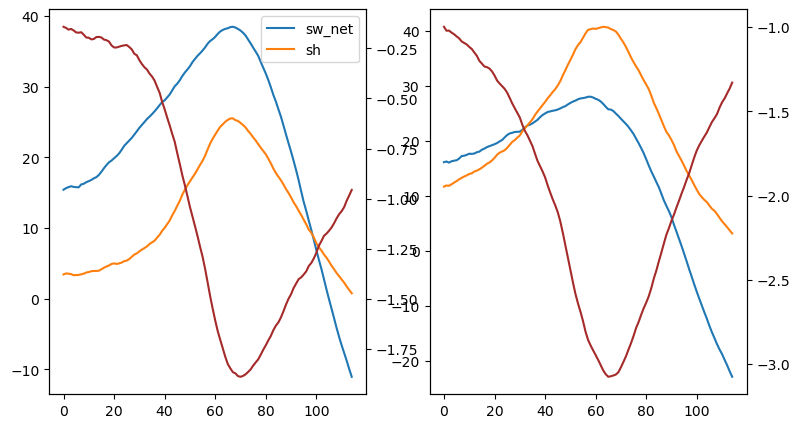

In [45]:
ticks = np.array([-57,-57/2,0,57/2,57])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]

var = 'sw_net'
var2 = 'sh'
var3='SM'

f = plt.figure(figsize=(9,5))
ax = f.add_subplot(121)
ax2 = ax.twinx()
ax.plot(ds[var], label=var)
ax.plot(ds[var2], label=var2)
ax.legend()
ax2.plot(ds[var3], label=var3, color='brown')

# ax.set_xticks(ticks)
# ax.set_xticklabels(labels)
# ax2.set_xticks(ticks)
# ax2.set_xticklabels(labels)


ax = f.add_subplot(122)
ax2 = ax.twinx()
ax.plot(ds2[var], label=var)
ax.plot(ds2[var2], label=var2)
ax2.plot(ds2[var3], label=var3, color='brown')

# ax.set_xticks(ticks)
# ax.set_xticklabels(labels)
# ax2.set_xticks(ticks)
# ax2.set_xticklabels(labels)

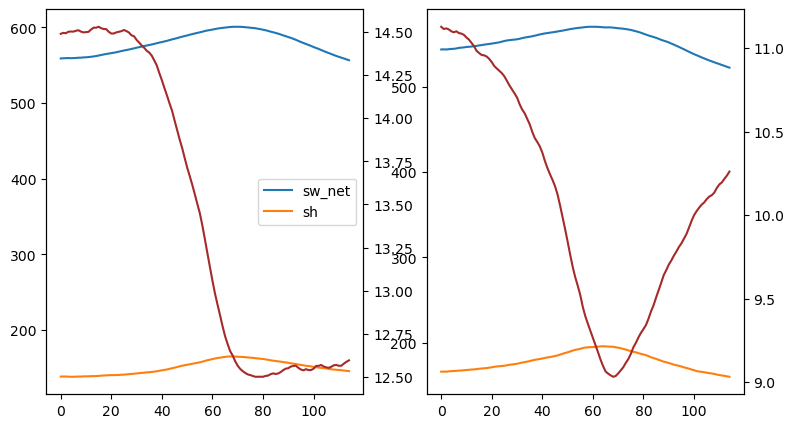

In [46]:
ticks = np.array([-57,-57/2,0,57/2,57])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]

var = 'sw_net'
var2 = 'sh'
var3='SM'

f = plt.figure(figsize=(9,5))
ax = f.add_subplot(121)
ax2 = ax.twinx()
ax.plot(mean[var], label=var)
ax.plot(mean[var2], label=var2)
ax.legend()
ax2.plot(mean[var3], label=var3, color='brown')

# ax.set_xticks(ticks)
# ax.set_xticklabels(labels)
# ax2.set_xticks(ticks)
# ax2.set_xticklabels(labels)


ax = f.add_subplot(122)
ax2 = ax.twinx()
ax.plot(mean2[var], label=var)
ax.plot(mean2[var2], label=var2)
ax2.plot(mean2[var3], label=var3, color='brown')

# ax.set_xticks(ticks)
# ax.set_xticklabels(labels)
# ax2.set_xticks(ticks)
# ax2.set_xticklabels(labels)

In [24]:
direction = 'YDIR'
strs='18'
merged_hist, merged_fut, merged_hist_mean, merged_fut_mean = get_anom_and_mean(direction='YDIR', strs='18')

file = 'hist_anom_all_'+strs+'h_'+direction+'.nc'
file2 = 'fut_anom_all_'+strs+'h_'+direction+'.nc'

mean = 'hist_mean_all_'+strs+'h_'+direction+'.nc'
mean2 = 'fut_mean_all_'+strs+'h_'+direction+'.nc'
    
ds = xr.open_dataset(cp4_path+file)
ds2 = xr.open_dataset(cp4_path+file2)

mean = xr.open_dataset(cp4_path+mean)
mean2 = xr.open_dataset(cp4_path+mean2)

from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0

lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.latitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(15,6), dpi=100)

for idx, data in enumerate([merged_hist, merged_fut]):

    ax = f.add_subplot(1,3,idx+1)

    mp=ax.contourf(data.latitude, data.pressure, (data['q_cross'])*1000, cmap='RdBu_r',levels=np.linspace(-0.9,0.9,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    num = ax.contour(data.latitude, data.pressure, (data['q_cross'])*1000, colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # Set major ticks locator for the y-axis to be every 100 steps
    ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # Set minor ticks locator for the y-axis to be every 20 steps
    ax.yaxis.set_minor_locator(MultipleLocator(20))
    #ax.set_ylim(980,600)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(data.latitude, mean['pblH'], label='PBLH_stormD hist')
        ax2.plot(data.latitude, mean['pblH']-ds['pblH'], label='PBLH_clim hist')
    # else:
    #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    ax2.set_ylim(0,3500)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)
    
    # cbar.label('Relative humidity (%)')
    plt.title('1200 UTC for 1800 UTC storm')
    plt.legend()
    
    plt.tight_layout()
    f.subplots_adjust(right=0.87)
    cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
    cbar = f.colorbar(mp, cax)
    cbar.set_label('Temperature anomaly (K)', fontsize=14)


ax = f.add_subplot(1,3,3)

mp=ax.contourf(data.latitude, data.pressure, (merged_fut['t_cross']-merged_hist['t_cross']), cmap='RdBu_r',levels=np.linspace(-0.9,0.9,10), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 

qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')

num = ax.contour(data.latitude, data.pressure, (merged_fut['q_cross']-merged_hist['q_cross'])*1000, colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')

# Set major ticks locator for the y-axis to be every 100 steps
ax.yaxis.set_major_locator(MultipleLocator(100))

# Set minor ticks locator for the y-axis to be every 20 steps
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(980,600)

ax.set_xlabel('Distance (km)', fontsize=14)
ax.set_ylabel('Pressure level (hPa)', fontsize=14)

plt.title('', fontsize=14)

# cbar.label('Relative humidity (%)')
plt.title('1200 UTC for 1800 UTC storm')
plt.legend()

plt.tight_layout()
f.subplots_adjust(right=0.87)
cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
cbar = f.colorbar(mp, cax)
cbar.set_label('Temperature anomaly (K)', fontsize=14)


#f.savefig('cross_18hstorms_ydir.png')

FileNotFoundError: [Errno 2] No such file or directory: b'/gws/nopw/j04/lmcs/cklein/CP_models/MCS_files/WAf/CP4_box_JASMIN/mean3h_v2/hist_anom_all_18h_YDIR.nc'

In [47]:
def calc_div(da):
    u = units.Quantity(da['u_cross'].values, 'm/s')
    v = units.Quantity(da['v_cross'].values, 'm/s')

    
    dx = units.Quantity(4400, 'm')
    div = calc.divergence(u,v, dx=dx, dy=dx)
    # vort = calc.shearing_deformation(u,v, dx, dx)
    da_div = da['u_cross'].copy(deep=True)
    da_div.values = div

    return da_div

In [9]:
strs='18'
direction='YDIR'

file = 'hist_anom_all_'+strs+'h_'+direction+'.nc'
filem = 'hist_mean_all_'+strs+'h_'+direction+'.nc'
file2 = 'fut_anom_all_'+strs+'h_'+direction+'.nc'
file2m = 'fut_mean_all_'+strs+'h_'+direction+'.nc'

file2d = 'hist_anom_all_'+strs+'h_2d.nc'
file2d2 = 'fut_anom_all_'+strs+'h_2d.nc'
file2d_mean = 'hist_mean_all_'+strs+'h_2d.nc'
file2d2_mean = 'fut_mean_all_'+strs+'h_2d.nc'

In [10]:
direction = 'YDIR'
merged_hist, merged_fut, merged_hist_mean, merged_fut_mean = get_anom_and_mean(direction='YDIR', strs='18')
file = 'hist_anom_all_'+strs+'h_'+direction+'.nc'
file2 = 'fut_anom_all_'+strs+'h_'+direction+'.nc'
    
ds = xr.open_dataset(cp4_path+file)
ds2 = xr.open_dataset(cp4_path+file2)

###########################

from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0
lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.latitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(15,6), dpi=100)

for idx, data in enumerate([merged_hist, merged_fut]):

    if idx == 0:
        dds = ds
    else:
        dds = ds2

    ax = f.add_subplot(1,3,idx+1)

    div = calc_div(data)

    thresh = np.max(np.abs(np.percentile(div, [5, 95])))
    mp=ax.contourf(div.latitude, div.pressure, div, cmap='RdBu_r',levels=np.linspace(thresh * -1, thresh, 12), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    # thresh = np.max(np.abs(np.percentile(data['u_cross'], [5, 95])))
    # mp=ax.contourf(data.latitude, data.pressure, data['u_cross'], cmap='RdBu_r',levels=np.linspace(thresh * -1, thresh, 12), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    
    plt.gca().invert_yaxis()
    num = ax.contour(data.latitude, data.pressure, (data['t_cross']), colors='k',levels=np.linspace(-0.9,0.9,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #num = ax.contour(data.latitude, dds.pressure, (dds['omega_cross'])*10, colors='purple',levels=np.linspace(-0.9,0.9,10), alpha=1, extend='both')
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    #num = ax.contour(data.latitude, data.pressure, (data['q_cross'])*1000, colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # Set major ticks locator for the y-axis to be every 100 steps
    ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # Set minor ticks locator for the y-axis to be every 20 steps
    ax.yaxis.set_minor_locator(MultipleLocator(20))
    ax.set_ylim(980,600)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    # if idx == 0:
    #     ax2.plot(ds_mean.latitude, ds_mean['pblH'], label='PBLH_stormD hist')
    #     ax2.plot(ds_mean.latitude, ds_mean['pblH']-ds['pblH'], label='PBLH_clim hist')
    # # else:
    # #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    # #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    # ax2.set_ylim(0,3500)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)
    
    # cbar.label('Relative humidity (%)')
    plt.title('1200 UTC for 1800 UTC storm')
    plt.legend()
    
    plt.tight_layout()
    f.subplots_adjust(right=0.87)
    cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
    cbar = f.colorbar(mp, cax)
    cbar.set_label('Temperature anomaly (K)', fontsize=14)


ax = f.add_subplot(1,3,3)
diffdiv = merged_fut['u_cross']-merged_hist['u_cross']#calc_div(merged_fut)-calc_div(merged_hist)
thresh = np.max(np.abs(np.percentile(diffdiv, [5, 95])))
mp=ax.contourf(data.latitude, data.pressure, diffdiv , cmap='RdBu_r',levels=np.linspace(thresh * -1, thresh, 12), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 

qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')

num = ax.contour(data.latitude, data.pressure, (merged_fut['t_cross']-merged_hist['t_cross']), colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')

# Set major ticks locator for the y-axis to be every 100 steps
ax.yaxis.set_major_locator(MultipleLocator(100))

# Set minor ticks locator for the y-axis to be every 20 steps
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(980,600)

ax.set_xlabel('Distance (km)', fontsize=14)
ax.set_ylabel('Pressure level (hPa)', fontsize=14)

plt.title('', fontsize=14)

# cbar.label('Relative humidity (%)')
plt.title('1200 UTC for 1800 UTC storm')
plt.legend()

plt.tight_layout()
f.subplots_adjust(right=0.87)
cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
cbar = f.colorbar(mp, cax)
cbar.set_label('Temperature anomaly (K)', fontsize=14)

FileNotFoundError: [Errno 2] No such file or directory: b'/gws/nopw/j04/lmcs/cklein/CP_models/MCS_files/CP4_box_JASMIN/hist_anom_all_18h_YDIR.nc'

In [11]:
direction = 'XDIR'
merged_hist, merged_fut, merged_hist_mean, merged_fut_mean = get_anom_and_mean(direction='XDIR', strs='18')
file = 'hist_anom_all_'+strs+'h_'+direction+'.nc'
file2 = 'fut_anom_all_'+strs+'h_'+direction+'.nc'
    
ds = xr.open_dataset(cp4_path+file)
ds2 = xr.open_dataset(cp4_path+file2)

###########################

from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0
lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.longitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(15,6), dpi=100)

for idx, data in enumerate([merged_hist_mean, merged_fut_mean]):

    ax = f.add_subplot(1,3,idx+1)

    div = calc_div(data)

    thresh = np.max(np.abs(np.percentile(div, [5, 95])))
    mp=ax.contourf(div.longitude, div.pressure, div, cmap='RdBu_r',levels=np.linspace(thresh * -1, thresh, 12), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    # thresh = np.max(np.abs(np.percentile(data['u_cross'], [5, 95])))
    # mp=ax.contourf(data.longitude, data.pressure, data['u_cross'], cmap='RdBu_r',levels=np.linspace(thresh * -1, thresh, 12), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    
    plt.gca().invert_yaxis()
    num = ax.contour(data.longitude, data.pressure, (data['t_cross']), colors='k',levels=np.linspace(-0.9,0.9,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    #num = ax.contour(data.latitude, data.pressure, (data['q_cross'])*1000, colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # Set major ticks locator for the y-axis to be every 100 steps
    ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # Set minor ticks locator for the y-axis to be every 20 steps
    ax.yaxis.set_minor_locator(MultipleLocator(20))
    ax.set_ylim(980,600)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    # if idx == 0:
    #     ax2.plot(ds_mean.latitude, ds_mean['pblH'], label='PBLH_stormD hist')
    #     ax2.plot(ds_mean.latitude, ds_mean['pblH']-ds['pblH'], label='PBLH_clim hist')
    # # else:
    # #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    # #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    # ax2.set_ylim(0,3500)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)
    
    # cbar.label('Relative humidity (%)')
    plt.title('1200 UTC for 1800 UTC storm')
    plt.legend()
    
    plt.tight_layout()
    f.subplots_adjust(right=0.87)
    cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
    cbar = f.colorbar(mp, cax)
    cbar.set_label('Temperature anomaly (K)', fontsize=14)


ax = f.add_subplot(1,3,3)
diffdiv = merged_fut['u_cross']-merged_hist['u_cross']#calc_div(merged_fut)-calc_div(merged_hist)
thresh = np.max(np.abs(np.percentile(diffdiv, [5, 95])))
mp=ax.contourf(data.longitude, data.pressure, diffdiv , cmap='RdBu_r',levels=np.linspace(thresh * -1, thresh, 12), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 

qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')

num = ax.contour(data.longitude, data.pressure, (merged_fut['t_cross']-merged_hist['t_cross']), colors='k',levels=np.linspace(-0.9,0.9,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#num = ax.contour(data.latitude, data.pressure, (merged_fut['q_cross']-merged_hist['q_cross'])*1000, colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')

# Set major ticks locator for the y-axis to be every 100 steps
ax.yaxis.set_major_locator(MultipleLocator(100))

# Set minor ticks locator for the y-axis to be every 20 steps
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(980,600)

ax.set_xlabel('Distance (km)', fontsize=14)
ax.set_ylabel('Pressure level (hPa)', fontsize=14)

plt.title('', fontsize=14)

# cbar.label('Relative humidity (%)')
plt.title('1200 UTC for 1800 UTC storm')
plt.legend()

plt.tight_layout()
f.subplots_adjust(right=0.87)
cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
cbar = f.colorbar(mp, cax)
cbar.set_label('Temperature anomaly (K)', fontsize=14)

FileNotFoundError: [Errno 2] No such file or directory: b'/gws/nopw/j04/lmcs/cklein/CP_models/MCS_files/CP4_box_JASMIN/hist_anom_all_18h_XDIR.nc'

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_559/434410399.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_559/434410399.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


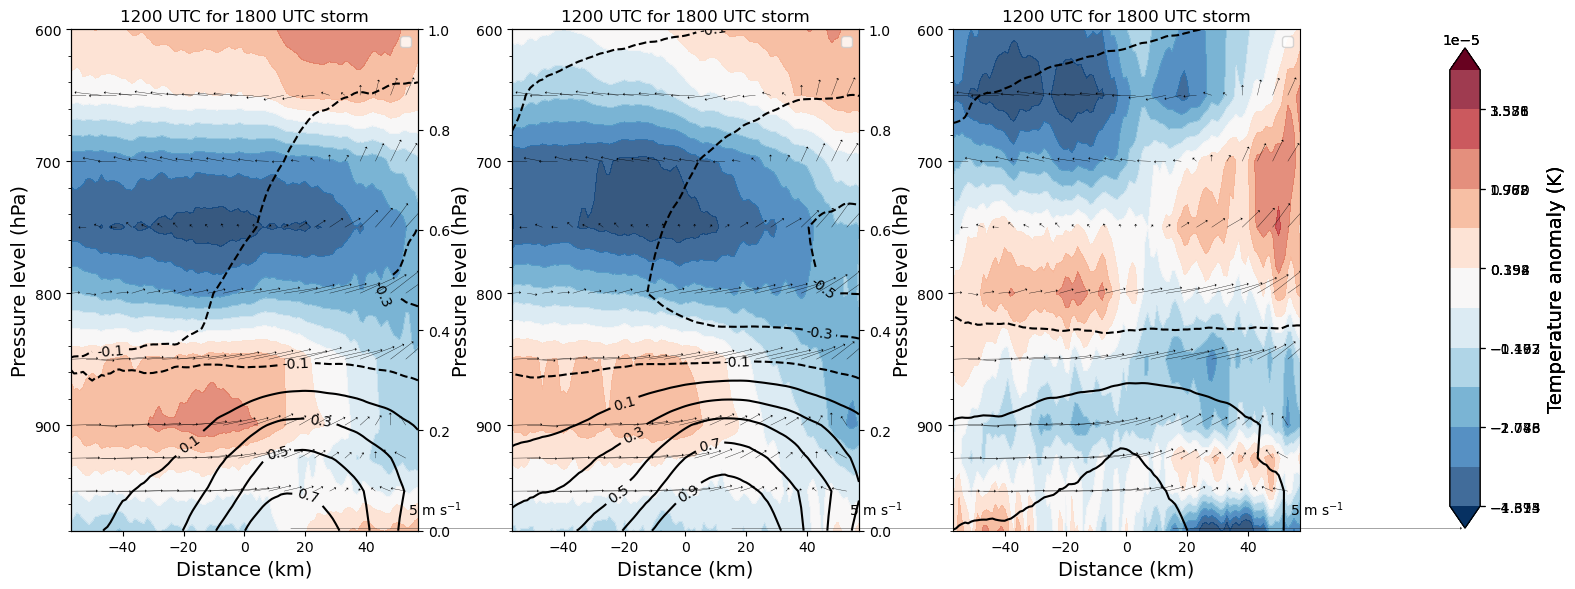

In [23]:
direction = 'XDIR'
merged_hist, merged_fut, merged_hist_mean, merged_fut_mean = get_anom_and_mean(direction='XDIR', strs='18')
file = 'hist_anom_all_'+strs+'h_'+direction+'.nc'
file2 = 'fut_anom_all_'+strs+'h_'+direction+'.nc'
    
ds = xr.open_dataset(cp4_path+file)
ds2 = xr.open_dataset(cp4_path+file2)

###########################

from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0
lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.longitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(15,6), dpi=100)

for idx, data in enumerate([merged_hist, merged_fut]):

    ax = f.add_subplot(1,3,idx+1)

    div = calc_div(data)

    thresh = np.max(np.abs(np.percentile(div, [5, 95])))
    mp=ax.contourf(div.longitude, div.pressure, div, cmap='RdBu_r',levels=np.linspace(thresh * -1, thresh, 12), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 

    plt.gca().invert_yaxis()
    num = ax.contour(data.longitude, data.pressure, (data['t_cross']), colors='k',levels=np.linspace(-0.9,0.9,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    #num = ax.contour(data.latitude, data.pressure, (data['q_cross'])*1000, colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # Set major ticks locator for the y-axis to be every 100 steps
    ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # Set minor ticks locator for the y-axis to be every 20 steps
    ax.yaxis.set_minor_locator(MultipleLocator(20))
    ax.set_ylim(980,600)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    # if idx == 0:
    #     ax2.plot(ds_mean.latitude, ds_mean['pblH'], label='PBLH_stormD hist')
    #     ax2.plot(ds_mean.latitude, ds_mean['pblH']-ds['pblH'], label='PBLH_clim hist')
    # # else:
    # #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    # #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    # ax2.set_ylim(0,3500)
    # print((ds_mean['pblH']-ds['pblH']).max())
    # print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)
    
    # cbar.label('Relative humidity (%)')
    plt.title('1200 UTC for 1800 UTC storm')
    plt.legend()
    
    plt.tight_layout()
    f.subplots_adjust(right=0.87)
    cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
    cbar = f.colorbar(mp, cax)
    cbar.set_label('Temperature anomaly (K)', fontsize=14)


ax = f.add_subplot(1,3,3)
diffdiv = calc_div(merged_fut)-calc_div(merged_hist)
thresh = np.max(np.abs(np.percentile(diffdiv, [5, 95])))
mp=ax.contourf(data.longitude, data.pressure, diffdiv , cmap='RdBu_r',levels=np.linspace(thresh * -1, thresh, 12), alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 

qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')

num = ax.contour(data.longitude, data.pressure, (merged_fut['t_cross']-merged_hist['t_cross']), colors='k',levels=np.linspace(-0.9,0.9,10), alpha=1, extend='both')
#num = ax.contour(data.latitude, data.pressure, (merged_fut['q_cross']-merged_hist['q_cross'])*1000, colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')

# Set major ticks locator for the y-axis to be every 100 steps
ax.yaxis.set_major_locator(MultipleLocator(100))

# Set minor ticks locator for the y-axis to be every 20 steps
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(980,600)

ax.set_xlabel('Distance (km)', fontsize=14)
ax.set_ylabel('Pressure level (hPa)', fontsize=14)

plt.title('', fontsize=14)

# cbar.label('Relative humidity (%)')
plt.title('1200 UTC for 1800 UTC storm')
plt.legend()

plt.tight_layout()
f.subplots_adjust(right=0.87)
cax = f.add_axes([0.97, 0.11, 0.02, 0.8])
cbar = f.colorbar(mp, cax)
cbar.set_label('Temperature anomaly (K)', fontsize=14)

In [133]:
def theta_anom(ds, ds_mean):
    #ipdb.set_trace()
    pes = units.Quantity(np.repeat(ds.pressure.values[:, np.newaxis],ds['t_cross'].values.shape[1], axis=1), 'hPa')

    tes = units.Quantity( (ds['t_cross']+ds_mean['t_cross']).values, 'K')
    theta_val_anom = calc.potential_temperature(pes, tes)

    tes = units.Quantity( (ds_mean['t_cross']).values, 'K')
    theta_val_mean = calc.potential_temperature(pes, tes)

    #ipdb.set_trace()

    theta = ds['t_cross'].copy(deep=True)
    theta.values = theta_val_anom-theta_val_mean

    return theta

In [134]:
def theta_e_anom(ds, ds_mean):
    #ipdb.set_trace()
    pes = units.Quantity(np.repeat(ds.pressure.values[:, np.newaxis],ds['t_cross'].values.shape[1], axis=1), 'hPa')

    tes = units.Quantity( (ds['t_cross']+ds_mean['t_cross']).values, 'K')
    qes = units.Quantity((ds['q_cross']+ds_mean['q_cross']).values, 'kg/kg')

    dew = calc.dewpoint_from_specific_humidity(pes, tes, qes)
    theta_val_anom = calc.equivalent_potential_temperature(pes, tes,dew)

    tes = units.Quantity( (ds_mean['t_cross']).values, 'K')
    qes = units.Quantity((ds_mean['q_cross']).values, 'kg/kg')
    dew = calc.dewpoint_from_specific_humidity(pes, tes, qes)
    theta_val_mean = calc.equivalent_potential_temperature(pes, tes,dew)

    #ipdb.set_trace()

    theta = ds['t_cross'].copy(deep=True)
    theta.values = theta_val_anom-theta_val_mean

    return theta

In [135]:
def theta_e(ds):
    #ipdb.set_trace()
    pes = units.Quantity(np.repeat(ds.pressure.values[:, np.newaxis],ds['t_cross'].values.shape[1], axis=1), 'hPa')

    tes = units.Quantity( (ds['t_cross']).values, 'K')
    qes = units.Quantity((ds['q_cross']).values, 'kg/kg')

    dew = calc.dewpoint_from_specific_humidity(pes, tes, qes)
    theta_val = calc.equivalent_potential_temperature(pes, tes,dew)

    #ipdb.set_trace()

    theta = ds['t_cross'].copy(deep=True)
    theta.values = theta_val

    return theta

In [136]:
def theta(ds):
    #ipdb.set_trace()
    pes = units.Quantity(np.repeat(ds.pressure.values[:, np.newaxis],ds['t_cross'].values.shape[1], axis=1), 'hPa')

    tes = units.Quantity( (ds['t_cross']).values, 'K')
    theta_val = calc.potential_temperature(pes, tes)

    #ipdb.set_trace()

    theta = ds['t_cross'].copy(deep=True)
    theta.values = theta_val

    return theta

In [137]:
def relative_humidity(ds):
    pes = units.Quantity(np.repeat(ds.pressure.values[:, np.newaxis],ds['t_cross'].values.shape[1], axis=1), 'hPa')
    tes = units.Quantity(ds['t_cross'].values, 'K')
    qes = units.Quantity(ds['q_cross'].values, 'kg/kg')

    rh = calc.relative_humidity_from_specific_humidity(pes, tes, qes)

    theta = ds['t_cross'].copy(deep=True)
    theta.values = rh

    return theta

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<xarray.DataArray 'pblH' ()>
array(1099.99854822)
<xarray.DataArray 'pblH' ()>
array(1162.52179132)
<xarray.DataArray 'pblH' ()>
array(1099.99854822)
<xarray.DataArray 'pblH' ()>
array(1162.52179132)


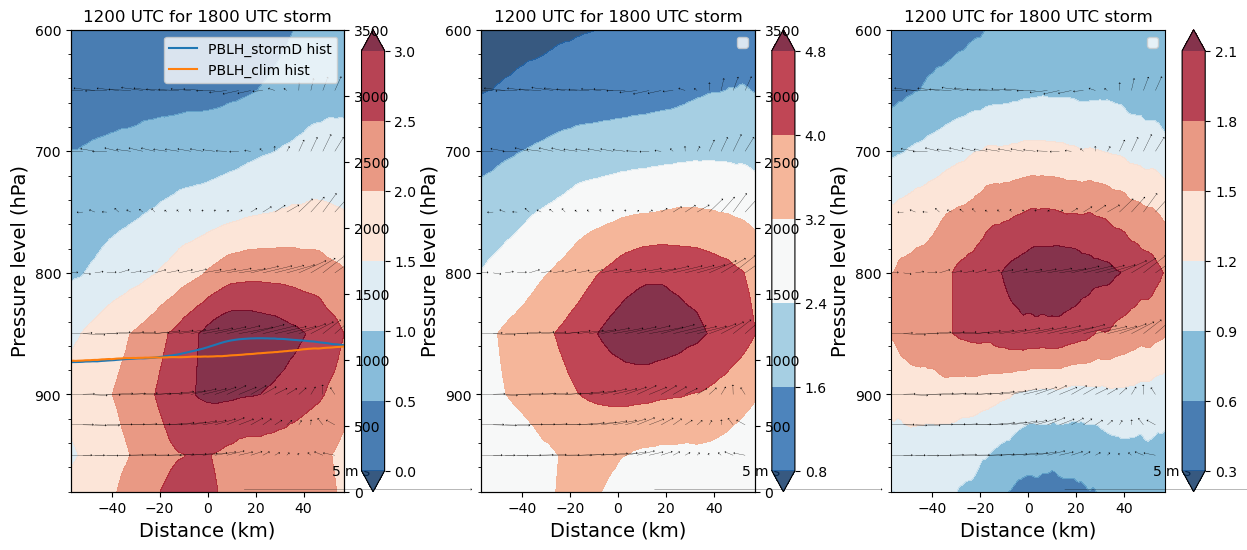

In [179]:
strs ='18'

file = 'hist_anom_all_'+strs+'h_XDIR.nc'
filem = 'hist_mean_all_'+strs+'h_XDIR.nc'
file2 = 'fut_anom_all_'+strs+'h_XDIR.nc'
file2m = 'fut_mean_all_'+strs+'h_XDIR.nc'

file2d = 'hist_anom_all_'+strs+'h_2d.nc'
file2d2 = 'fut_anom_all_'+strs+'h_2d.nc'
file2d_mean = 'hist_mean_all_'+strs+'h_2d.nc'
file2d2_mean = 'fut_mean_all_'+strs+'h_2d.nc'

###########################

ds = xr.open_dataset(cp4_path+file)
ds2 = xr.open_dataset(cp4_path+file2)

ds_mean = xr.open_dataset(cp4_path+filem)
ds2_mean = xr.open_dataset(cp4_path+file2m)

#######################################

ds2d = xr.open_dataset(cp4_path+file2d)
ds2d2 = xr.open_dataset(cp4_path+file2d2)

ds2d = ds2d.sel(latitude=slice(-6,6)).mean('latitude')
ds2d2 = ds2d2.sel(latitude=slice(-6,6)).mean('latitude')
ds3 = ds2d[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross', 'v_srfc' : 'v_cross'})
ds32 = ds2d2[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross',  'v_srfc' : 'v_cross'})

merged_hist = ds[['t_cross', 'q_cross', 'u_cross', 'v_cross']]
merged_fut = ds2[['t_cross', 'q_cross', 'u_cross', 'v_cross']]

# Add pressure level dimension to the extra dataset
pressure_level_980 = 980  # Define the pressure level value
ds3 = ds3.expand_dims(dim={'pressure': [pressure_level_980]})
ds3 = ds3.assign_coords(pressure=('pressure', [pressure_level_980]))
merged_hist = xr.concat([ds3, merged_hist], dim='pressure')

ds32 = ds32.expand_dims(dim={'pressure': [pressure_level_980]})
ds32 = ds32.assign_coords(pressure=('pressure', [pressure_level_980]))
merged_fut = xr.concat([ds32, merged_fut], dim='pressure')

#####################################

#######################################

ds2d = xr.open_dataset(cp4_path+file2d_mean)
ds2d2 = xr.open_dataset(cp4_path+file2d2_mean)

ds2d = ds2d.sel(latitude=slice(-6,6)).mean('latitude')
ds2d2 = ds2d2.sel(latitude=slice(-6,6)).mean('latitude')
ds3_m = ds2d[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross', 'v_srfc' : 'v_cross'})
ds32_m = ds2d2[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross',  'v_srfc' : 'v_cross'})

merged_hist_mean = ds_mean[['t_cross', 'q_cross', 'u_cross', 'v_cross']]
merged_fut_mean = ds2_mean[['t_cross', 'q_cross', 'u_cross', 'v_cross']]

# Add pressure level dimension to the extra dataset
pressure_level_980 = 980  # Define the pressure level value
ds3_m = ds3_m.expand_dims(dim={'pressure': [pressure_level_980]})
ds3_m = ds3_m.assign_coords(pressure=('pressure', [pressure_level_980]))
merged_hist_mean = xr.concat([ds3_m, merged_hist_mean], dim='pressure')

ds32_m = ds32_m.expand_dims(dim={'pressure': [pressure_level_980]})
ds32_m = ds32_m.assign_coords(pressure=('pressure', [pressure_level_980]))
merged_fut_mean = xr.concat([ds32_m, merged_fut_mean], dim='pressure')


##################################

from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0
lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.longitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(15,6), dpi=100)

dat_means = [merged_hist_mean, merged_fut_mean]

for idx, data in enumerate([merged_hist, merged_fut]):

    ax = f.add_subplot(1,3,idx+1)
    
    div = theta_e_anom(data, dat_means[idx])
    thresh = np.nanmax(np.abs(np.percentile(div, [5, 95])))

    mp=ax.contourf(div.longitude, div.pressure, div, cmap='RdBu_r', alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
    plt.colorbar(mp)
    
    cbar.set_label('Temperature anomaly (K)', fontsize=14)
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    #num = ax.contour(data.latitude, data.pressure, (data['q_cross'])*1000, colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # Set major ticks locator for the y-axis to be every 100 steps
    ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # Set minor ticks locator for the y-axis to be every 20 steps
    ax.yaxis.set_minor_locator(MultipleLocator(20))
    ax.set_ylim(980,600)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(ds_mean.longitude, ds_mean['pblH'], label='PBLH_stormD hist')
        ax2.plot(ds_mean.longitude, ds_mean['pblH']-ds['pblH'], label='PBLH_clim hist')
    # else:
    #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    ax2.set_ylim(0,3500)
    print((ds_mean['pblH']-ds['pblH']).max())
    print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)
    
    # cbar.label('Relative humidity (%)')
    plt.title('1200 UTC for 1800 UTC storm')
    plt.legend()


ax = f.add_subplot(1,3,3)
diffdiv = theta_e_anom(merged_fut, merged_fut_mean)-theta_e_anom(merged_hist, merged_hist_mean)
thresh = np.max(np.abs(np.percentile(diffdiv, [25, 75])))
mp=ax.contourf(data.longitude, data.pressure, diffdiv , cmap='RdBu_r', alpha=0.8, extend='both') #levels=np.linspace(-70,5,50), 
plt.colorbar(mp)
qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')

#num = ax.contour(data.latitude, data.pressure, (merged_fut['q_cross']-merged_hist['q_cross'])*1000, colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')

# Set major ticks locator for the y-axis to be every 100 steps
ax.yaxis.set_major_locator(MultipleLocator(100))

# Set minor ticks locator for the y-axis to be every 20 steps
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(980,600)

ax.set_xlabel('Distance (km)', fontsize=14)
ax.set_ylabel('Pressure level (hPa)', fontsize=14)

plt.title('', fontsize=14)

# cbar.label('Relative humidity (%)')
plt.title('1200 UTC for 1800 UTC storm')
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<xarray.DataArray 'pblH' ()>
array(0.)
<xarray.DataArray 'pblH' ()>
array(1162.52179132)
<xarray.DataArray 'pblH' ()>
array(0.)
<xarray.DataArray 'pblH' ()>
array(1162.52179132)


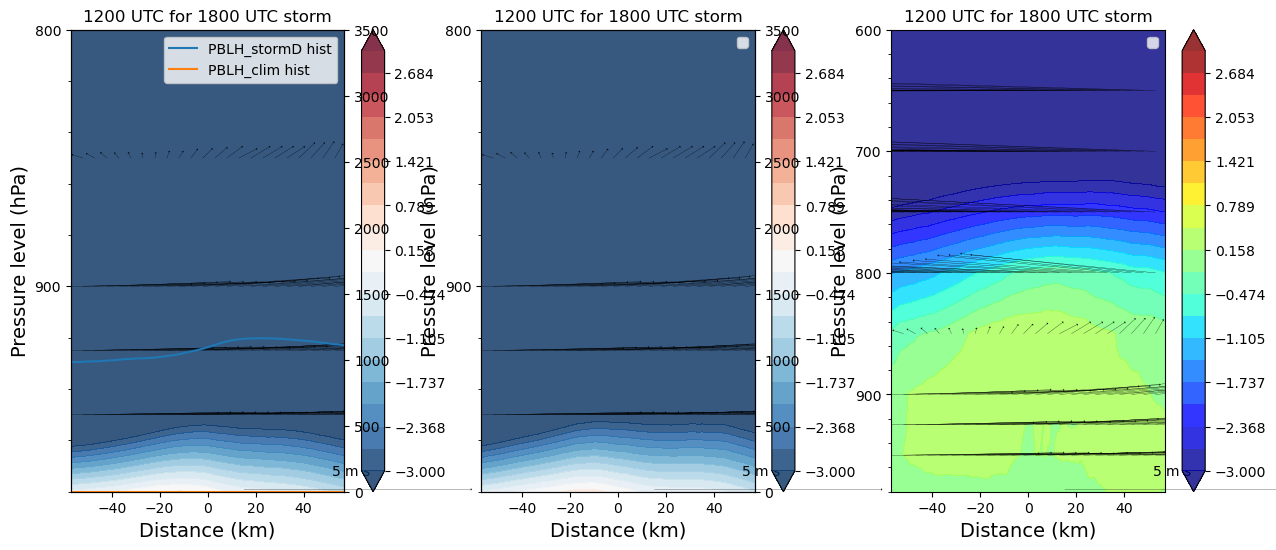

In [155]:
strs ='18'

file = 'hist_mean_all_'+strs+'h_XDIR.nc'
filem = 'hist_mean_all_'+strs+'h_XDIR.nc'
file2 = 'fut_mean_all_'+strs+'h_XDIR.nc'
file2m = 'fut_mean_all_'+strs+'h_XDIR.nc'

file2d = 'hist_mean_all_'+strs+'h_2d.nc'
file2d2 = 'fut_mean_all_'+strs+'h_2d.nc'
file2d_mean = 'hist_mean_all_'+strs+'h_2d.nc'
file2d2_mean = 'fut_mean_all_'+strs+'h_2d.nc'

###########################

ds = xr.open_dataset(cp4_path+file)
ds2 = xr.open_dataset(cp4_path+file2)

ds_mean = xr.open_dataset(cp4_path+filem)
ds2_mean = xr.open_dataset(cp4_path+file2m)

#######################################

ds2d = xr.open_dataset(cp4_path+file2d)
ds2d2 = xr.open_dataset(cp4_path+file2d2)

ds2d = ds2d.sel(latitude=slice(-6,6)).mean('latitude')
ds2d2 = ds2d2.sel(latitude=slice(-6,6)).mean('latitude')
ds3 = ds2d[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross', 'v_srfc' : 'v_cross'})
ds32 = ds2d2[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross',  'v_srfc' : 'v_cross'})

merged_hist = ds[['t_cross', 'q_cross', 'u_cross', 'v_cross']]
merged_fut = ds2[['t_cross', 'q_cross', 'u_cross', 'v_cross']]

# Add pressure level dimension to the extra dataset
pressure_level_980 = 980  # Define the pressure level value
ds3 = ds3.expand_dims(dim={'pressure': [pressure_level_980]})
ds3 = ds3.assign_coords(pressure=('pressure', [pressure_level_980]))
merged_hist = xr.concat([ds3, merged_hist], dim='pressure')

ds32 = ds32.expand_dims(dim={'pressure': [pressure_level_980]})
ds32 = ds32.assign_coords(pressure=('pressure', [pressure_level_980]))
merged_fut = xr.concat([ds32, merged_fut], dim='pressure')

#####################################


from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0
lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.longitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]

f = plt.figure(figsize=(15,6), dpi=100)

dat_means = [merged_hist_mean, merged_fut_mean]

for idx, data in enumerate([merged_hist, merged_fut]):

    ax = f.add_subplot(1,3,idx+1)
    
    div = theta_e(data)
    #ipdb.set_trace()
    div = (div-div[0,59])
    thresh = np.nanmax(np.abs(np.percentile(div, [5, 95])))
    #ipdb.set_trace()
    mp=ax.contourf(div.longitude, div.pressure, div, cmap='RdBu_r', alpha=0.8, extend='both', levels=np.linspace(-3,3,20)) #levels=np.linspace(-70,5,50), 
    plt.colorbar(mp)
    
    cbar.set_label('Temperature anomaly (K)', fontsize=14)
    plt.gca().invert_yaxis()
    
    qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
    plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')
    
    #num = ax.contour(data.latitude, data.pressure, (data['q_cross'])*1000, colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
    #ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')
    
    # Set major ticks locator for the y-axis to be every 100 steps
    ax.yaxis.set_major_locator(MultipleLocator(100))
    
    # Set minor ticks locator for the y-axis to be every 20 steps
    ax.yaxis.set_minor_locator(MultipleLocator(20))
    ax.set_ylim(980,800)
    
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_ylabel('Pressure level (hPa)', fontsize=14)
    ax2 = ax.twinx()

    if idx == 0:
        ax2.plot(ds_mean.longitude, ds_mean['pblH'], label='PBLH_stormD hist')
        ax2.plot(ds_mean.longitude, ds_mean['pblH']-ds['pblH'], label='PBLH_clim hist')
    # else:
    #     ax2.plot(merged_hist.longitude, ds2_mean['pblH'], label='PBLH_stormD fut')
    #     ax2.plot(ds_mean.longitude, ds2_mean['pblH']-ds2['pblH'], label='PBLH_clim fut')
        
    ax2.set_ylim(0,3500)
    print((ds_mean['pblH']-ds['pblH']).max())
    print((ds_mean['pblH']).max())

    
    plt.title('', fontsize=14)
    
    # cbar.label('Relative humidity (%)')
    plt.title('1200 UTC for 1800 UTC storm')
    plt.legend()


ax = f.add_subplot(1,3,3)
divfut = theta_e(merged_fut)
divfut = (divfut-divfut[0,59])
divhist = theta_e(merged_hist)
divhist = (divhist-divhist[0,59])
thresh = np.max(np.abs(np.percentile(diffdiv, [25, 75])))
mp=ax.contourf(data.longitude, data.pressure, divfut-divhist , cmap='jet', alpha=0.8, extend='both', levels=np.linspace(-3,3,20)) #levels=np.linspace(-70,5,50), 
plt.colorbar(mp)
qv = ax.quiver(xquiv, yquiv, uu, vv*-1, scale=6, width=0.001, headwidth=9)
plt.quiverkey(qv,1.05, 0.005, 5, r'5 m s$^{-1}$')

#num = ax.contour(data.latitude, data.pressure, (merged_fut['q_cross']-merged_hist['q_cross'])*1000, colors='k',levels=np.linspace(-2,2,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.contour(ds_mean.longitude, ds_mean.pressure, (ds_mean['q_cross']-ds['q_cross'])*1000, colors='k',levels=np.linspace(12,15,10), alpha=1, extend='both') #levels=np.linspace(-70,5,50), 
#ax.clabel(num, inline=True, fontsize=10, fmt='%1.1f')

# Set major ticks locator for the y-axis to be every 100 steps
ax.yaxis.set_major_locator(MultipleLocator(100))

# Set minor ticks locator for the y-axis to be every 20 steps
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(980,600)

ax.set_xlabel('Distance (km)', fontsize=14)
ax.set_ylabel('Pressure level (hPa)', fontsize=14)

plt.title('', fontsize=14)

# cbar.label('Relative humidity (%)')
plt.title('1200 UTC for 1800 UTC storm')
plt.legend()

In [164]:
def skew_vars(ds):
    #ipdb.set_trace()
    pes = units.Quantity(ds.pressure.values, 'hPa')

    tes = units.Quantity( (ds['t_cross']).values[:,58], 'K')
    qes = units.Quantity((ds['q_cross']).values[:,58], 'kg/kg')

    dew = calc.dewpoint_from_specific_humidity(pes, tes, qes)

    return pes , tes, dew

In [168]:
from metpy.plots import add_metpy_logo, SkewT
from metpy.units import units
import metpy.calc as mpcalc

In [191]:
strs ='18'

file = 'hist_mean_all_'+strs+'h_XDIR.nc'
filem = 'hist_mean_all_'+strs+'h_XDIR.nc'
file2 = 'fut_mean_all_'+strs+'h_XDIR.nc'
file2m = 'fut_mean_all_'+strs+'h_XDIR.nc'

file2d = 'hist_mean_all_'+strs+'h_2d.nc'
file2d2 = 'fut_mean_all_'+strs+'h_2d.nc'
file2d_mean = 'hist_mean_all_'+strs+'h_2d.nc'
file2d2_mean = 'fut_mean_all_'+strs+'h_2d.nc'

###########################

ds = xr.open_dataset(cp4_path+file)
ds2 = xr.open_dataset(cp4_path+file2)

ds_mean = xr.open_dataset(cp4_path+filem)
ds2_mean = xr.open_dataset(cp4_path+file2m)

#######################################

ds2d = xr.open_dataset(cp4_path+file2d)
ds2d2 = xr.open_dataset(cp4_path+file2d2)

ds2d = ds2d.sel(latitude=slice(-6,6)).mean('latitude')
ds2d2 = ds2d2.sel(latitude=slice(-6,6)).mean('latitude')
ds3 = ds2d[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross', 'v_srfc' : 'v_cross'})
ds32 = ds2d2[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross',  'v_srfc' : 'v_cross'})

merged_hist = ds[['t_cross', 'q_cross', 'u_cross', 'v_cross']]
merged_fut = ds2[['t_cross', 'q_cross', 'u_cross', 'v_cross']]

# Add pressure level dimension to the extra dataset
pressure_level_980 = 980  # Define the pressure level value
ds3 = ds3.expand_dims(dim={'pressure': [pressure_level_980]})
ds3 = ds3.assign_coords(pressure=('pressure', [pressure_level_980]))
merged_hist = xr.concat([ds3, merged_hist], dim='pressure')

ds32 = ds32.expand_dims(dim={'pressure': [pressure_level_980]})
ds32 = ds32.assign_coords(pressure=('pressure', [pressure_level_980]))
merged_fut = xr.concat([ds32, merged_fut], dim='pressure')

#####################################

from matplotlib.ticker import MultipleLocator, AutoMinorLocator
st=1
sarrow = 0
lowres= 5

ucross = ds['u_cross']
cross = ds['omega_cross']*3

xquiv = ucross.longitude[sarrow::lowres]
yquiv = ucross.pressure[sarrow::st]

uu = ucross[sarrow::st, sarrow::lowres]
vv = cross[sarrow::st, sarrow::lowres]


def skewp(data, mean):

    fig = plt.figure(figsize=(9, 9))


    p,T,Td = skew_vars(data)

    ax = f.add_subplot(1,2,idx+1)
    
    
    skew = SkewT(fig, rotation=45)
    
    # Plot the data using normal plotting functions, in this case using
    # log scaling in Y, as dictated by the typical meteorological plot.
    skew.plot(p, T, 'r')
    skew.plot(p, Td, 'g')
    
    skew.ax.set_ylim(1000, 400)
    skew.ax.set_xlim(10, 40)
    
    
    # Calculate LCL height and plot as black dot. Because `p`'s first value is
    # ~1000 mb and its last value is ~250 mb, the `0` index is selected for
    # `p`, `T`, and `Td` to lift the parcel from the surface. If `p` was inverted,
    # i.e. start from low value, 250 mb, to a high value, 1000 mb, the `-1` index
    # should be selected.
    lcl_pressure, lcl_temperature = mpcalc.lcl(p[0], T[0], Td[0])
    skew.plot(lcl_pressure, lcl_temperature, 'ko', markerfacecolor='black')
    
    # Calculate full parcel profile and add to plot as black line
    prof = mpcalc.parcel_profile(p, T[0], Td[0]).to('degC')
    skew.plot(p, prof, 'k', linewidth=2)
    
    # Shade areas of CAPE and CIN
    skew.shade_cin(p, T, prof, Td)
    skew.shade_cape(p, T, prof)
    
    # An example of a slanted line at constant T -- in this case the 0
    # isotherm
    skew.ax.axvline(0, color='c', linestyle='--', linewidth=2)
    
    # Add the relevant special lines
    skew.plot_dry_adiabats()
    skew.plot_moist_adiabats()
    skew.plot_mixing_lines()

    p, T, Td = skew_vars(mean)

# Plot the data using normal plotting functions, in this case using
    # log scaling in Y, as dictated by the typical meteorological plot.
    skew.plot(p, T, 'orange')
    skew.plot(p, Td, 'blue')
    
    skew.ax.set_ylim(1000, 400)
    skew.ax.set_xlim(10, 40)
    
    
    # Calculate LCL height and plot as black dot. Because `p`'s first value is
    # ~1000 mb and its last value is ~250 mb, the `0` index is selected for
    # `p`, `T`, and `Td` to lift the parcel from the surface. If `p` was inverted,
    # i.e. start from low value, 250 mb, to a high value, 1000 mb, the `-1` index
    # should be selected.
    lcl_pressure, lcl_temperature = mpcalc.lcl(p[0], T[0], Td[0])
    skew.plot(lcl_pressure, lcl_temperature, 'ko', markerfacecolor='gold')
    
    # Calculate full parcel profile and add to plot as black line
    prof = mpcalc.parcel_profile(p, T[0], Td[0]).to('degC')
    skew.plot(p, prof, 'purple', linewidth=2)
    
    # Shade areas of CAPE and CIN
    skew.shade_cin(p, T, prof, Td)
    skew.shade_cape(p, T, prof)
    
    

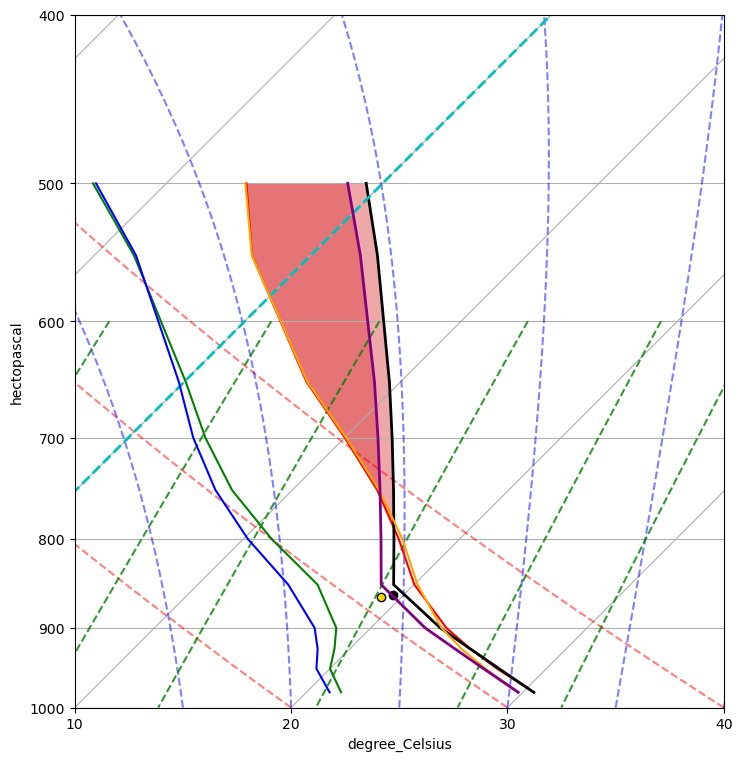

In [193]:
skewp(merged_hist, merged_hist_clim)

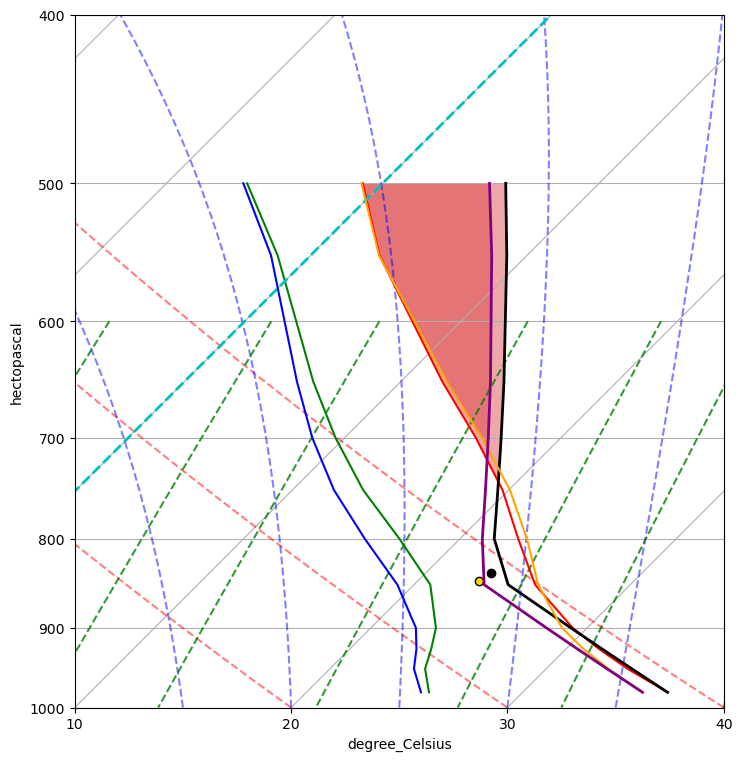

In [194]:
skewp(merged_fut, merged_fut_clim)

In [188]:
strs ='18'

file = 'hist_anom_all_'+strs+'h_XDIR.nc'
filem = 'hist_mean_all_'+strs+'h_XDIR.nc'
file2 = 'fut_anom_all_'+strs+'h_XDIR.nc'
file2m = 'fut_mean_all_'+strs+'h_XDIR.nc'

file2d = 'hist_anom_all_'+strs+'h_2d.nc'
file2d2 = 'fut_anom_all_'+strs+'h_2d.nc'
file2d_mean = 'hist_mean_all_'+strs+'h_2d.nc'
file2d2_mean = 'fut_mean_all_'+strs+'h_2d.nc'

###########################

ds = xr.open_dataset(cp4_path+file)
ds2 = xr.open_dataset(cp4_path+file2)

ds_mean = xr.open_dataset(cp4_path+filem)
ds2_mean = xr.open_dataset(cp4_path+file2m)

#######################################

ds2d = xr.open_dataset(cp4_path+file2d)
ds2d2 = xr.open_dataset(cp4_path+file2d2)

ds2d = ds2d.sel(latitude=slice(-6,6)).mean('latitude')
ds2d2 = ds2d2.sel(latitude=slice(-6,6)).mean('latitude')
ds3 = ds2d[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross', 'v_srfc' : 'v_cross'})
ds32 = ds2d2[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross',  'v_srfc' : 'v_cross'})

merged_hist = ds[['t_cross', 'q_cross', 'u_cross', 'v_cross']]
merged_fut = ds2[['t_cross', 'q_cross', 'u_cross', 'v_cross']]

# Add pressure level dimension to the extra dataset
pressure_level_980 = 980  # Define the pressure level value
ds3 = ds3.expand_dims(dim={'pressure': [pressure_level_980]})
ds3 = ds3.assign_coords(pressure=('pressure', [pressure_level_980]))
merged_hist = xr.concat([ds3, merged_hist], dim='pressure')

ds32 = ds32.expand_dims(dim={'pressure': [pressure_level_980]})
ds32 = ds32.assign_coords(pressure=('pressure', [pressure_level_980]))
merged_fut = xr.concat([ds32, merged_fut], dim='pressure')

#####################################

#######################################

ds2d = xr.open_dataset(cp4_path+file2d_mean)
ds2d2 = xr.open_dataset(cp4_path+file2d2_mean)

ds2d = ds2d.sel(latitude=slice(-6,6)).mean('latitude')
ds2d2 = ds2d2.sel(latitude=slice(-6,6)).mean('latitude')
ds3_m = ds2d[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross', 'v_srfc' : 'v_cross'})
ds32_m = ds2d2[['t2', 'q2','u_srfc', 'v_srfc']].rename({'t2' : 't_cross', 'q2' : 'q_cross', 'u_srfc' : 'u_cross',  'v_srfc' : 'v_cross'})

merged_hist_mean = ds_mean[['t_cross', 'q_cross', 'u_cross', 'v_cross']]
merged_fut_mean = ds2_mean[['t_cross', 'q_cross', 'u_cross', 'v_cross']]

# Add pressure level dimension to the extra dataset
pressure_level_980 = 980  # Define the pressure level value
ds3_m = ds3_m.expand_dims(dim={'pressure': [pressure_level_980]})
ds3_m = ds3_m.assign_coords(pressure=('pressure', [pressure_level_980]))
merged_hist_mean = xr.concat([ds3_m, merged_hist_mean], dim='pressure')

ds32_m = ds32_m.expand_dims(dim={'pressure': [pressure_level_980]})
ds32_m = ds32_m.assign_coords(pressure=('pressure', [pressure_level_980]))
merged_fut_mean = xr.concat([ds32_m, merged_fut_mean], dim='pressure')

merged_hist_clim = merged_hist_mean-merged_hist
merged_fut_clim = merged_fut_mean-merged_fut